# Lecture 8: Linear Models

## Contents
- [8.1 Bivariate data](#section-81)
- [8.2 The bivariate model](#section-82)
- [8.3 Posterior regression parameters](#section-83)
- [8.4 Centered and uncentered data](#section-84)
- [8.5 Multivariate regression](#section-85)
- [8.6 Multivariate regression posterior](#section-86)
- [8.7 Frequentist methods](#section-87)
- [8.8 Next time](#section-88)


## Setup

## Data access policy
This notebook is designed to run cleanly in Colab without requiring students to clone the full course repository. Lecture 8 uses first-visit rows from the OASIS longitudinal dementia MRI dataset and downloads the CSV only if it is not found locally.

In [145]:
import importlib.util
import subprocess
import sys

IS_COLAB = "google.colab" in sys.modules


def ensure_package(pip_name, import_name=None):
    name = import_name or pip_name
    if importlib.util.find_spec(name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])


for pip_name, import_name in [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("pymc", "pymc"),
    ("arviz", "arviz"),
    ("preliz", "preliz"),
]:
    ensure_package(pip_name, import_name)

## Required data files

In [146]:
REQUIRED_DATA_FILES = {
    "oasis_dementia_mri.csv": "https://vincentarelbundock.github.io/Rdatasets/csv/NeuroDataSets/oasis_dementia_mri_df.csv",
}

## Resolve required data files

In [147]:
from pathlib import Path
import urllib.request

SEARCH_DIRS = [
    Path("."),
    Path("data"),
    Path("Data"),
    Path("public_content") / "Data",
    Path("..") / "data",
    Path("..") / "Data",
    Path("..") / "public_content" / "Data",
]

DATA_FILE_PATHS = {}
for filename, url in REQUIRED_DATA_FILES.items():
    local_path = next((folder / filename for folder in SEARCH_DIRS if (folder / filename).exists()), None)
    if local_path is None:
        data_dir = Path("data")
        data_dir.mkdir(exist_ok=True)
        local_path = data_dir / filename
        urllib.request.urlretrieve(url, local_path)
    DATA_FILE_PATHS[filename] = local_path

DATA_FILE_PATHS

{'oasis_dementia_mri.csv': WindowsPath('../public_content/Data/oasis_dementia_mri.csv')}

## Imports and plotting defaults
Plots use the Lecture 7 teaching palette: charcoal for observed data, blue for `nWBV` and mean curves, orange for reference values and Age accents, green for posterior predictive and MMSE accents, and purple or magenta when a second comparison color helps.

In [148]:
import os
import warnings

TMP_NUMBA_DIR = "/tmp/numba-codex"
TMP_PYTENSOR_DIR = "/tmp/pytensor-codex"
os.makedirs(TMP_NUMBA_DIR, exist_ok=True)
os.makedirs(TMP_PYTENSOR_DIR, exist_ok=True)
os.environ.setdefault("NUMBA_CACHE_DIR", TMP_NUMBA_DIR)
os.environ.setdefault("PYTENSOR_BASE_COMPILEDIR", TMP_PYTENSOR_DIR)
os.environ.setdefault("PYTENSOR_FLAGS", f"base_compiledir={TMP_PYTENSOR_DIR}")

from IPython.display import Markdown, display
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import preliz as pz
import xarray as xr

print(f"arviz: {az.__version__}")
print(f"pymc: {pm.__version__}")
print(f"preliz: {pz.__version__}")
print(f"xarray: {xr.__version__}")

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_SEED = 36714361
rng = np.random.default_rng(RANDOM_SEED)

plt.rcParams["figure.figsize"] = (8, 4.8)
plt.rcParams["figure.dpi"] = 150
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
az.style.use("arviz-whitegrid")

COLORS = {
    "observed": "#30343B",
    "nwbv": "#0072B2",
    "mean": "#0072B2",
    "normal": "#0072B2",
    "prior": "#A65E00",
    "posterior": "#006D4E",
    "predictive": "#009E73",
    "younger": "#56B4E9",
    "older": "#D55E00",
    "first": "#0072B2",
    "last": "#CC79A7",
    "change": "#6A3D9A",
    "student_t": "#009E73",
    "female": "#CC79A7",
    "male": "#009E73",
    "reference": "#D55E00",
    "rope": "#F0E442",
    "age": "#D55E00",
    "mmse": "#009E73",
    "etiv": "#6A3D9A",
    "frequentist": "#6A3D9A",
    "neutral": "#A65E00",
    "light": "#D9ECF7",
}

LABELS = {
    "Age": "Age (years)",
    "Age_c": "Age (years from mean)",
    "Age_z": "Age (SD units)",
    "MMSE": "MMSE (points)",
    "MMSE_c": "MMSE (points from mean)",
    "MMSE_z": "MMSE (SD units)",
    "nWBV": "nWBV (fraction eTIV)",
    "nWBV_z": "nWBV (SD units)",
    "eTIV": "eTIV (cm^3)",
    "eTIV_z": "eTIV (SD units)",
}

arviz: 0.23.4
pymc: 5.28.1
preliz: 0.24.0
xarray: 2025.3.1


## Load and derive analysis data frames

In [ ]:
oasis = pd.read_csv(DATA_FILE_PATHS["oasis_dementia_mri.csv"])
oasis = oasis.drop(columns=[col for col in ["rownames", "Hand"] if col in oasis.columns])
oasis = oasis.sort_values(["Subject.ID", "Visit", "MR.Delay"]).reset_index(drop=True)

first_visit = (
    oasis.sort_values(["Subject.ID", "Visit", "MR.Delay"])
    .groupby("Subject.ID", as_index=False)
    .first()
)

simple_df = first_visit.dropna(subset=["Age", "nWBV"]).copy()
simple_df["Age_c"] = simple_df["Age"] - simple_df["Age"].mean()
simple_df["Age_z"] = simple_df["Age_c"] / simple_df["Age"].std(ddof=1)
simple_df["nWBV_z"] = (
    simple_df["nWBV"] - simple_df["nWBV"].mean()
) / simple_df["nWBV"].std(ddof=1)

mmse_simple_df = first_visit.dropna(subset=["MMSE", "nWBV"]).copy()
mmse_simple_df["MMSE_c"] = mmse_simple_df["MMSE"] - mmse_simple_df["MMSE"].mean()
mmse_simple_df["MMSE_z"] = mmse_simple_df["MMSE_c"] / mmse_simple_df["MMSE"].std(ddof=1)
mmse_simple_df["nWBV_z"] = (
    mmse_simple_df["nWBV"] - mmse_simple_df["nWBV"].mean()
) / mmse_simple_df["nWBV"].std(ddof=1)

multiple_df = first_visit.dropna(subset=["Age", "MMSE", "nWBV"]).copy()
multiple_df["Age_c"] = multiple_df["Age"] - multiple_df["Age"].mean()
multiple_df["MMSE_c"] = multiple_df["MMSE"] - multiple_df["MMSE"].mean()
multiple_df["Age_z"] = multiple_df["Age_c"] / multiple_df["Age"].std(ddof=1)
multiple_df["MMSE_z"] = multiple_df["MMSE_c"] / multiple_df["MMSE"].std(ddof=1)
multiple_df["nWBV_z"] = (
    multiple_df["nWBV"] - multiple_df["nWBV"].mean()
) / multiple_df["nWBV"].std(ddof=1)

print(f"Full OASIS rows: {len(oasis)}")
print(f"First-visit subjects: {len(first_visit)}")
print(f"Rows for nWBV ~ Age: {len(simple_df)}")
print(f"Rows for nWBV ~ MMSE: {len(mmse_simple_df)}")
print(f"Rows for nWBV ~ Age + MMSE: {len(multiple_df)}")


## Helper functions

In [150]:
def format_whole_number(value):
    if pd.isna(value):
        return "—"
    return f"{value:,.0f}"


def fixed_decimals(decimals, thousands=False):
    spec = f",.{decimals}f" if thousands else f".{decimals}f"

    def formatter(value):
        if pd.isna(value):
            return "—"
        return format(float(value), spec)

    return formatter


def format_p_value(value):
    if pd.isna(value):
        return "—"
    if value < 1e-4:
        return "<0.0001"
    return f"{value:.4f}"


def pretty_table(df, caption, formats=None, format_rules=None, hide_index=True):
    styler = df.style
    if hide_index:
        styler = styler.hide(axis="index")
    if formats:
        styler = styler.format(formats, na_rep="—")
    if format_rules:
        for row_selector, col_selector, formatter in format_rules:
            styler = styler.format(formatter, subset=pd.IndexSlice[row_selector, col_selector], na_rep="—")
    return (
        styler
        .set_caption(caption)
        .set_table_styles(
            [
                {"selector": "caption", "props": "caption-side: top; font-size: 1.1rem; font-weight: 700; text-align: left; padding: 0 0 0.35rem 0; color: #1f2937;"},
                {"selector": "th", "props": "background-color: #0072B2; color: white; font-weight: 700; text-align: left; padding: 0.45rem 0.6rem; border: 1px solid white;"},
                {"selector": "td", "props": "padding: 0.45rem 0.6rem; border: 1px solid white; vertical-align: top; text-align: left;"},
                {"selector": "tbody tr:nth-child(odd)", "props": "background-color: #d9ecf7;"},
                {"selector": "tbody tr:nth-child(even)", "props": "background-color: #eef7fb;"},
            ]
        )
        .set_properties(**{"font-size": "0.95rem", "line-height": "1.25"})
    )


def style_axis(ax, title=None, xlabel=None, ylabel=None):
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    return ax


def two_sig_fig_str(value):
    if pd.isna(value) or np.isclose(value, 0):
        return "0"
    magnitude = int(np.floor(np.log10(abs(value))))
    rounded = round(float(value), 1 - magnitude)
    decimals = max(0, 1 - magnitude)
    return f"{rounded:.{decimals}f}"


def set_compact_tick_labels(ax, axis="x", n_ticks=3):
    getter = ax.get_xlim if axis == "x" else ax.get_ylim
    set_ticks = ax.set_xticks if axis == "x" else ax.set_yticks
    set_labels = ax.set_xticklabels if axis == "x" else ax.set_yticklabels
    lower, upper = getter()
    ticks = np.linspace(lower, upper, n_ticks)
    set_ticks(ticks)
    set_labels([two_sig_fig_str(tick) for tick in ticks])


def add_zero_line(ax, orientation="vertical", **kwargs):
    defaults = {"color": COLORS["reference"], "lw": 1.6, "ls": "--", "alpha": 0.9}
    defaults.update(kwargs)
    if orientation == "vertical":
        ax.axvline(0, **defaults)
    else:
        ax.axhline(0, **defaults)


def add_hdi_interval(ax, samples, y=0, hdi_prob=0.94, color=None):
    hdi = az.hdi(np.asarray(samples), hdi_prob=hdi_prob)
    color = color or COLORS["posterior"]
    ax.hlines(y, hdi[0], hdi[1], color=color, lw=5)
    return hdi


def plot_rope(ax, rope, orientation="vertical", color=COLORS["rope"], alpha=0.25):
    if orientation == "vertical":
        ax.axvspan(rope[0], rope[1], color=color, alpha=alpha, label="ROPE")
    else:
        ax.axhspan(rope[0], rope[1], color=color, alpha=alpha, label="ROPE")


def extract_posterior(idata, var_name, group="posterior"):
    return az.extract(idata, group=group, var_names=var_name).to_numpy().reshape(-1)


def posterior_matrix(idata, var_name):
    return az.extract(idata, group="posterior", var_names=var_name).transpose("sample", ...).to_numpy()


def ppc_matrix(idata, var_name):
    return az.extract(idata, group="posterior_predictive", var_names=var_name).transpose("sample", ...).to_numpy()


def prediction_matrix(idata, var_name):
    return az.extract(idata, group="predictions", var_names=var_name).transpose("sample", ...).to_numpy()


def summarize_draws(draws, hdi_prob=0.94):
    draws = np.asarray(draws)
    return {
        "mean": draws.mean(axis=0),
        "median": np.median(draws, axis=0),
        "hdi": az.hdi(draws, hdi_prob=hdi_prob),
    }


def sample_model_predictions(model, idata, data_updates, coords, restore_data, restore_coords, var_names=("mu", "nwbv_obs")):
    with model:
        pm.set_data(data_updates, coords=coords)
        predictions = pm.sample_posterior_predictive(
            idata,
            var_names=list(var_names),
            predictions=True,
            return_inferencedata=True,
            random_seed=RANDOM_SEED,
            progressbar=False,
        )
        pm.set_data(restore_data, coords=restore_coords)
    return predictions


def bayesian_r2_from_mu_sigma(mu_samples, sigma_samples):
    var_mu = np.var(mu_samples, axis=1, ddof=1)
    return var_mu / (var_mu + sigma_samples**2)


def assign_bayesian_r2(idata, var_name="r2"):
    var_mu = idata.posterior["mu"].var(dim="obs_id", ddof=1)
    r2 = var_mu / (var_mu + idata.posterior["sigma"] ** 2)
    idata.posterior = idata.posterior.assign({var_name: r2})
    return idata.posterior[var_name]


def rope_hdi_summary(samples, rope, hdi_prob=0.94):
    hdi = az.hdi(np.asarray(samples), hdi_prob=hdi_prob)
    inside = (hdi[0] >= rope[0]) and (hdi[1] <= rope[1])
    outside = (hdi[1] < rope[0]) or (hdi[0] > rope[1])
    return {"hdi_lower": hdi[0], "hdi_upper": hdi[1], "inside": inside, "outside": outside, "overlap": not inside and not outside}


def manual_mvn_pdf(grid, mean, cov):
    centered = grid - mean
    inv_cov = np.linalg.inv(cov)
    exponent = np.einsum("...i,ij,...j->...", centered, inv_cov, centered)
    norm_const = np.sqrt(((2 * np.pi) ** mean.size) * np.linalg.det(cov))
    return np.exp(-0.5 * exponent) / norm_const


def normal_pdf(x, mu, sigma):
    z = (np.asarray(x) - mu) / sigma
    return np.exp(-0.5 * z**2) / (sigma * np.sqrt(2 * np.pi))


def plot_density_line(samples, ax, color, label, lw=2.2, bins=40):
    ax.hist(np.asarray(samples), bins=bins, density=True, histtype="step", color=color, lw=lw, label=label)

## Data tables

In [ ]:
dataset_overview = pd.DataFrame(
    [
        {"Quantity": "Full OASIS rows", "Value": len(oasis)},
        {"Quantity": "First-visit subjects", "Value": first_visit["Subject.ID"].nunique()},
        {"Quantity": "nWBV ~ Age rows", "Value": len(simple_df)},
        {"Quantity": "nWBV ~ MMSE rows", "Value": len(mmse_simple_df)},
        {"Quantity": "nWBV ~ Age + MMSE rows", "Value": len(multiple_df)},
    ]
)

analysis_variables = pd.DataFrame(
    [
        {"Variable": "nWBV", "Meaning": "Normalized whole-brain volume", "Units": "Fraction", "Role today": "Gaussian outcome"},
        {"Variable": "Age", "Meaning": "Age at first MRI visit", "Units": "years", "Role today": "main predictor"},
        {"Variable": "MMSE", "Meaning": "Cognitive screening score; higher is better", "Units": "points", "Role today": "clinical predictor"},
    ]
)

summary_stats = (
    first_visit[["Age", "MMSE", "nWBV"]]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .T.reset_index()
    .rename(columns={"index": "Variable"})
)

summary_stat_format_rules = [
    (summary_stats.index, ["count"], format_whole_number),
    (
        summary_stats.index[summary_stats["Variable"].isin(["Age", "MMSE"])],
        ["mean", "std", "min", "median", "max"],
        fixed_decimals(1),
    ),
    (
        summary_stats.index[summary_stats["Variable"].eq("nWBV")],
        ["mean", "std", "min", "median", "max"],
        fixed_decimals(3),
    ),
]

display(pretty_table(dataset_overview, "Table 8.0A: Analysis rows", formats={"Value": format_whole_number}))
display(pretty_table(analysis_variables, "Table 8.0B: Variables used in this lecture"))
display(pretty_table(summary_stats, "Table 8.0C: Summary statistics", format_rules=summary_stat_format_rules))


<a id="section-81"></a>
## 8.1 Bivariate data
The lecture begins with paired continuous variables: age, normalized whole brain volume (`nWBV`), and MMSE. We keep `nWBV` on its native fraction scale throughout this notebook.

The model sequence is:
1. `nWBV ~ Age`
2. `nWBV ~ Age_c`
3. `nWBV ~ Age_c + MMSE_c`
4. Frequentist translation of the multiple-regression model


### 8.1.03 What we've learned so far

The course-map visual is maintained in the slide deck. The notebook begins the computational thread with the data relationships that support slide 8.1.04.

### 8.1.04 Today's models relate age, brain volume, and cognitive function

Figure ID: F02. The raw scatter begins the notebook's data view for the model sequence.

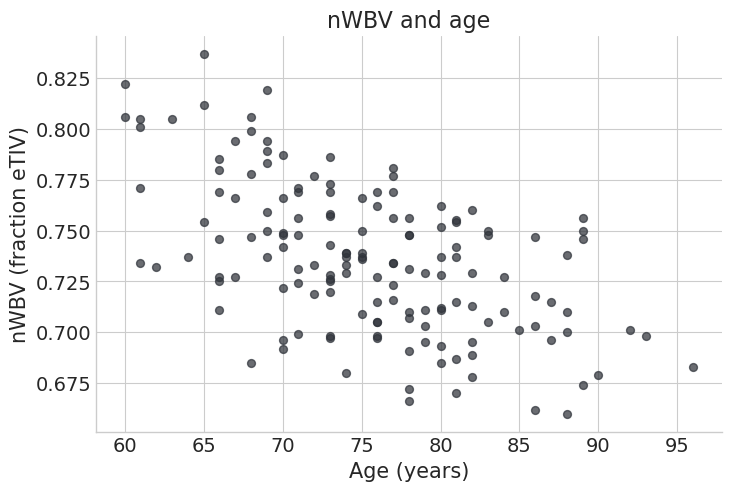

In [152]:
fig, ax = plt.subplots()
ax.scatter(simple_df["Age"], simple_df["nWBV"], s=32, color=COLORS["observed"], alpha=0.72)
style_axis(ax, "nWBV and age", LABELS["Age"], LABELS["nWBV"])
plt.show()

Additional raw-variable view for slide 8.1.04.

In [ ]:
multi_predictor_specs = [
    ("Age", simple_df, "Age"),
    ("MMSE", mmse_simple_df, "MMSE"),
]

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.9), sharey=True)
for idx, (ax, (xlabel, df, xvar)) in enumerate(zip(axes, multi_predictor_specs)):
    ax.scatter(df[xvar], df["nWBV"], s=24, alpha=0.48, color=COLORS["observed"])
    style_axis(ax, None, xlabel, "nWBV" if idx == 0 else "")
    ax.xaxis.label.set_size(14)
    ax.yaxis.label.set_size(14)
    ax.tick_params(axis="both", labelsize=12)
    ax.margins(x=0.05, y=0.08)
    set_compact_tick_labels(ax, axis="x", n_ticks=3)

set_compact_tick_labels(axes[0], axis="y", n_ticks=4)
axes[1].tick_params(axis="y", left=False, labelleft=False)

plt.tight_layout()
plt.show()


<a id="section-82"></a>
## 8.2 The bivariate model
The fitted model is `nWBV_i ~ Normal(mu_i, sigma)` with `mu_i = beta0 + beta1 Age_data_i`. In this first version, `Age_data_i` is raw age in years, so `beta0` is the extrapolated expected nWBV at age 0. We introduce centering later to make the intercept local.

### 8.2.06 Generalizing the two group normal model

This is a slide-deck bridge from two group means to observation-specific means; the executable model begins with the normal likelihood and PyMC cells below.

### 8.2.07 Linear regression has a normal likelihood

Figure ID: F04. This is a conceptual mean function, not an OLS fit.

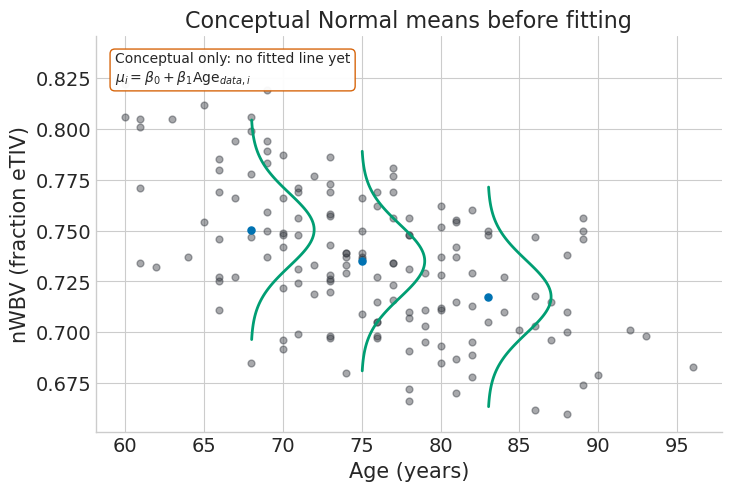

In [154]:
age_grid = np.linspace(simple_df["Age"].min(), simple_df["Age"].max(), 200)
age_grid_c = age_grid - simple_df["Age"].mean()
concept_beta0_age = 0.90
concept_beta1_age = -0.0022
concept_sigma_nwbv_age = 0.018

fig, ax = plt.subplots()
ax.scatter(simple_df["Age"], simple_df["nWBV"], s=24, color=COLORS["observed"], alpha=0.42)
for age_value in np.quantile(simple_df["Age"], [0.15, 0.5, 0.85]):
    mu_value = concept_beta0_age + concept_beta1_age * age_value
    y_curve = np.linspace(mu_value - 3 * concept_sigma_nwbv_age, mu_value + 3 * concept_sigma_nwbv_age, 120)
    density = normal_pdf(y_curve, mu_value, concept_sigma_nwbv_age)
    x_curve = age_value + 4.0 * density / density.max()
    ax.plot(x_curve, y_curve, color=COLORS["predictive"], lw=2)
    ax.scatter([age_value], [mu_value], s=26, color=COLORS["mean"], zorder=3)
ax.text(
    0.03,
    0.96,
    r"""Conceptual only: no fitted line yet
$\mu_i = \beta_0 + \beta_1 \operatorname{Age}_{data,i}$""",
    transform=ax.transAxes,
    va="top",
    bbox={"boxstyle": "round,pad=0.35", "fc": "white", "ec": COLORS["reference"], "alpha": 0.95},
)
style_axis(ax, "Conceptual Normal means before fitting", LABELS["Age"], LABELS["nWBV"])
plt.show()


### 8.2.08 There is an asymmetry in the model

Figure IDs: F05/F06. This supports slides 8.2.08 and 8.2.09.

```mermaid
flowchart
    Age(("Age")) --> nWBV(("nWBV"))

    style Age width:70px,height:70px
    style nWBV width:70px,height:70px
```

### 8.2.10 We translate the formal idea into a graphical model

Prior constants for the raw-age model. The graphical model needs priors before it can become executable PyMC.

These priors are weakly regularizing for the raw-age parameterization. Because `beta0` is the extrapolated expected nWBV at age 0, it must be broad enough to allow adult-age means near the observed range after adding `beta1 * Age_data`. A slope around `-0.002` nWBV units per year and an intercept around `0.90` imply an expected nWBV near `0.75` at the mean observed age, while the prior still allows flatter, steeper, and even mildly positive age trends. The broad prior predictive spread is part of the lesson: independent priors on an uncentered intercept and slope create awkward geometry, which centering will address later.

In [155]:
age_data = simple_df["Age"].astype(float)
nwbv_data = simple_df["nWBV"]

mu_1 = 0.0
sigma_1 = 0.03
mu_0 = np.mean(nwbv_data) - mu_1 * np.mean(age_data)
sigma_0 = 0.5*sigma_1*np.mean(age_data) 
sigma_sigma = 0.05

prior_predictive_samples = 400
posterior_draws = 1000
posterior_tune = 1000
posterior_chains = 4
target_accept = 0.95

pz.Normal(mu=mu_1, sigma=sigma_1)

priors_df = pd.DataFrame(
    {
        "Parameter": ["Intercept (mu_0)", "Age slope (mu_1)", "Residual SD (sigma)"],
        "Distribution": ["Normal", "Normal", "Half-Normal"],
        "Parameters": [
            f"mu={mu_0:.3f}, sigma={sigma_0:.3f}",
            f"mu={mu_1:.3f}, sigma={sigma_1:.3f}",
            f"sigma={sigma_sigma:.3f}",
        ],
    }
)

display(pretty_table(priors_df, "Table 8.1: Prior specifications for the simple linear regression model", hide_index=False))
display(pretty_table(priors_df, "Table 8.1: Prior specifications for the simple linear regression model", hide_index=False).to_html()) 

,Parameter,Distribution,Parameters
0,Intercept (mu_0),Normal,"mu=0.736, sigma=1.132"
1,Age slope (mu_1),Normal,"mu=0.000, sigma=0.030"
2,Residual SD (sigma),Half-Normal,sigma=0.050


'<style type="text/css">\n#T_e515d caption {\n  caption-side: top;\n  font-size: 1.1rem;\n  font-weight: 700;\n  text-align: left;\n  padding: 0 0 0.35rem 0;\n  color: #1f2937;\n}\n#T_e515d th {\n  background-color: #0072B2;\n  color: white;\n  font-weight: 700;\n  text-align: left;\n  padding: 0.45rem 0.6rem;\n  border: 1px solid white;\n}\n#T_e515d td {\n  padding: 0.45rem 0.6rem;\n  border: 1px solid white;\n  vertical-align: top;\n  text-align: left;\n}\n#T_e515d tbody tr:nth-child(odd) {\n  background-color: #d9ecf7;\n}\n#T_e515d tbody tr:nth-child(even) {\n  background-color: #eef7fb;\n}\n#T_e515d_row0_col0, #T_e515d_row0_col1, #T_e515d_row0_col2, #T_e515d_row1_col0, #T_e515d_row1_col1, #T_e515d_row1_col2, #T_e515d_row2_col0, #T_e515d_row2_col1, #T_e515d_row2_col2 {\n  font-size: 0.95rem;\n  line-height: 1.25;\n}\n</style>\n<table id="T_e515d">\n  <caption>Table 8.1: Prior specifications for the simple linear regression model</caption>\n  <thead>\n    <tr>\n      <th class="blank

### 8.2.11 From graphical model to PyMC

In [157]:
coords_age = {"obs_id": np.arange(len(simple_df))}

with pm.Model(coords=coords_age) as nwbv_age_model:
    Age_data = pm.Data("Age_data", age_data, dims="obs_id")
    beta0 = pm.Normal("beta0", mu=mu_0, sigma=sigma_0)
    beta1 = pm.Normal("beta1", mu=mu_1, sigma=sigma_1)
    sigma = pm.HalfNormal("sigma", sigma=sigma_sigma)
    mu = pm.Deterministic("mu", beta0 + beta1 * Age_data, dims="obs_id")
    nwbv_obs = pm.Normal("nwbv_obs", mu=mu, sigma=sigma, observed=nwbv_data, dims="obs_id")


### 8.2.12 From PyMC to graphical representation

Figure ID: F08.

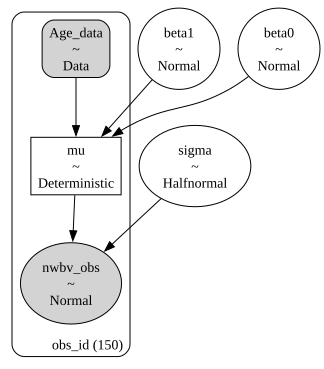

In [158]:
try:
    display(pm.model_to_graphviz(nwbv_age_model, var_names=["beta0", "beta1", "sigma", "Age_data", "mu", "nwbv_obs"]))
except Exception as exc:
    print("Graphviz is not available in this environment.")
    print(nwbv_age_model)
    print(exc)


Bayesian workflow for the uncentered Age model: prior predictive check, sampling, diagnostics, posterior predictive checks, then interpretation.
Before introducing centering, run the workflow on the raw-age model: prior predictive checks, sampling diagnostics, posterior predictive checks, and prediction across Age. Parameter interpretation waits until those checks exist.

### 8.2.13 Priors for β₀, β₁, and σ depend on the regression equation

Figure ID: F09.

Sampling: [beta0, beta1, nwbv_obs, sigma]


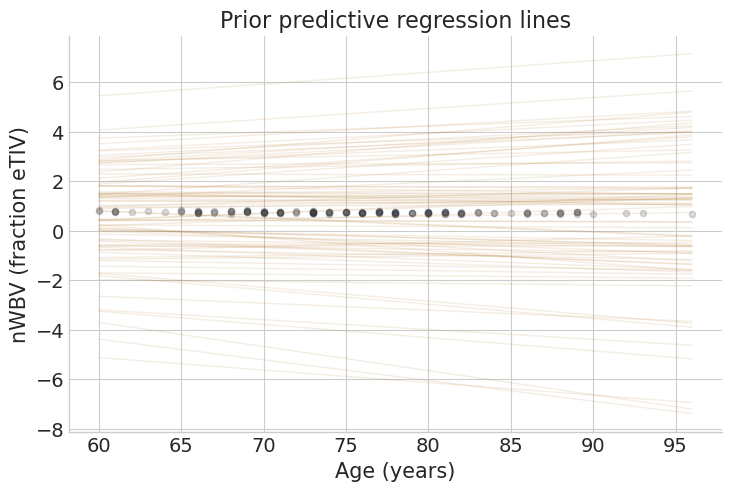

In [159]:
with nwbv_age_model:
    nwbv_age_prior = pm.sample_prior_predictive(samples=prior_predictive_samples, random_seed=RANDOM_SEED)

prior_beta0 = nwbv_age_prior.prior["beta0"].values.reshape(-1)
prior_beta1 = nwbv_age_prior.prior["beta1"].values.reshape(-1)

fig, ax = plt.subplots()
ax.scatter(simple_df["Age"], simple_df["nWBV"], s=20, color=COLORS["observed"], alpha=0.18)
for idx in rng.choice(prior_beta0.size, size=80, replace=False):
    ax.plot(age_grid, prior_beta0[idx] + prior_beta1[idx] * age_grid, color=COLORS["prior"], alpha=0.11, lw=1)
style_axis(ax, "Prior predictive regression lines", LABELS["Age"], LABELS["nWBV"])
plt.show()


### 8.2.14 Sampling looks ok

In [161]:
with nwbv_age_model:
    nwbv_age_idata = pm.sample(
        draws=posterior_draws,
        tune=posterior_tune,
        chains=posterior_chains,
        cores=1,
        target_accept=target_accept,
        random_seed=RANDOM_SEED,
        progressbar=False,
    )
    pm.sample_posterior_predictive(
        nwbv_age_idata,
        random_seed=RANDOM_SEED,
        progressbar=False,
        extend_inferencedata=True,
    )


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [beta0, beta1, sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 12 seconds.
Sampling: [nwbv_obs]


For slide 8.2.14: Sampling looks ok.

Figure ID: F10.

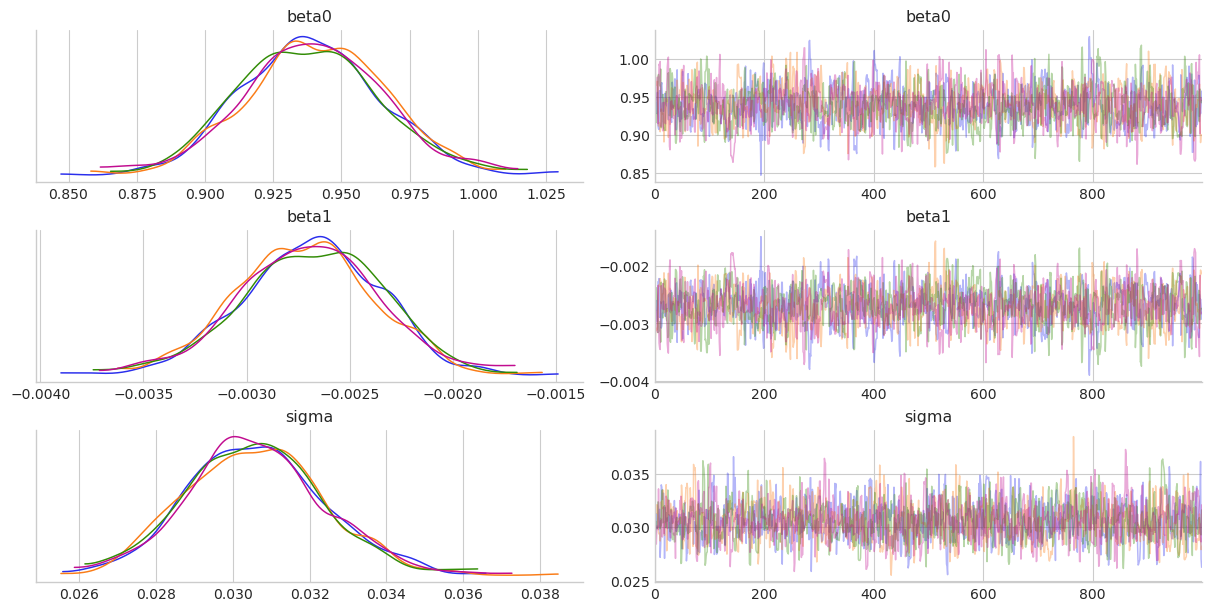

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta0,0.939,0.026,0.892,0.987,0.001,0.001,1215.0,1578.0,1.0
beta1,-0.003,0.000,-0.003,-0.002,0.000,0.000,1229.0,1646.0,1.0
sigma,0.031,0.002,0.027,0.034,0.000,0.000,1776.0,1674.0,1.0


In [162]:
az.plot_trace(nwbv_age_idata, var_names=["beta0", "beta1", "sigma"], compact=False)
plt.show()
az.summary(nwbv_age_idata, var_names=["beta0", "beta1", "sigma"])


### 8.2.15 Posterior predictive distribution looks ok

Figure ID: F11.

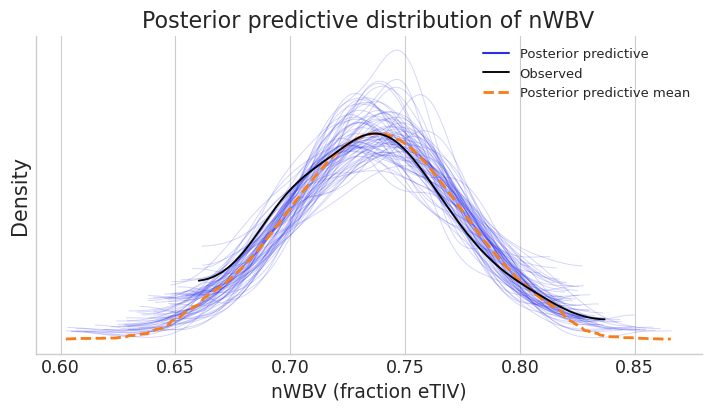

In [163]:
ax = az.plot_ppc(
    nwbv_age_idata,

    var_names=["nwbv_obs"],
    num_pp_samples=80,
    kind="kde",
    figsize=(7, 4),
)
ax.set_title("Posterior predictive distribution of nWBV")
ax.set_xlabel(LABELS["nWBV"])
ax.set_ylabel("Density")
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_33264\1168532392.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


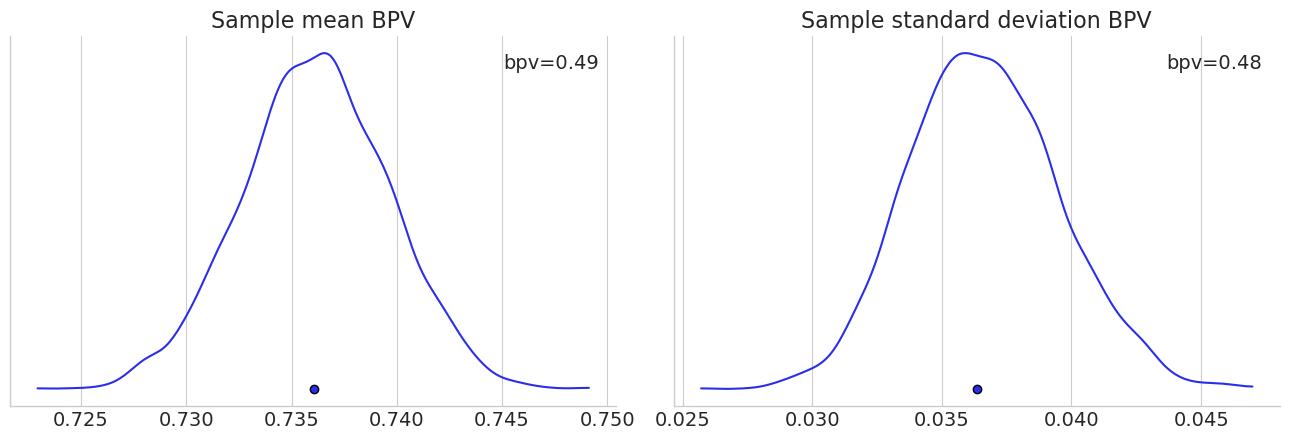

In [164]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

az.plot_bpv(
    nwbv_age_idata,
    var_names=["nwbv_obs"],
    kind="t_stat",
    t_stat = 'mean',
    ax=ax[0],
)

az.plot_bpv(
    nwbv_age_idata,
    var_names=["nwbv_obs"],
    kind="t_stat",
    t_stat = 'std',
    ax=ax[1],
)

ax[0].set_title("Sample mean BPV")
ax[1].set_title("Sample standard deviation BPV")
plt.tight_layout()

### 8.2.16 sample_posterior_predictive can predict on new data

The prediction-data workflow is used below to draw posterior-derived mean and predictive uncertainty across an age grid.


### 8.2.17 Posterior predictive shows model fit

Figure IDs: F12/F13. This cell also contains the prediction-data workflow shown on slide 8.2.16.

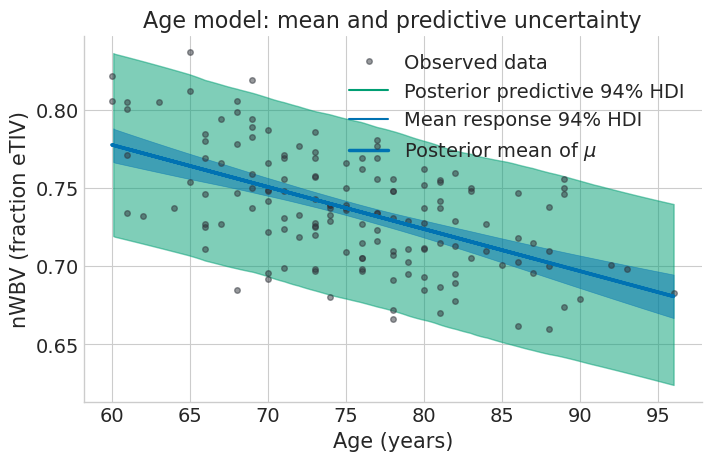

In [225]:
nwbv_age_beta0 = nwbv_age_idata.posterior["beta0"].stack(sample=("chain", "draw"))
nwbv_age_beta1 = nwbv_age_idata.posterior["beta1"].stack(sample=("chain", "draw"))
nwbv_age_sigma = nwbv_age_idata.posterior["sigma"].stack(sample=("chain", "draw"))

with az.rc_context({"stats.ci_prob": 0.94}):
    axes = az.plot_lm(
        y="nwbv_obs",
        x="Age_data",
        y_model="mu",
        y_hat="nwbv_obs",
        idata=nwbv_age_idata,
        kind_pp="hdi",
        kind_model="hdi",
        figsize=(7, 4.5),
        y_kwargs={
            "color": COLORS["observed"],
            "marker": "o",
            "markersize": 4,
            "linewidth": 0,
            "alpha": 0.5,
            "label": "Observed data",
        },
        y_hat_fill_kwargs={"color": COLORS["predictive"]},
        y_model_fill_kwargs={"color": COLORS["mean"]},
        y_model_mean_kwargs={"color": COLORS["mean"], "linewidth": 2.5},
        show=False,
    )

ax = axes[0, 0]
ax.set_xlabel(LABELS["Age"])
ax.set_ylabel(LABELS["nWBV"])
ax.set_title("Age model: mean and predictive uncertainty")

handles, labels = ax.get_legend_handles_labels()
legend_labels = {
    "Posterior predictive samples": "Posterior predictive 94% HDI",
    "Uncertainty in mean": "Mean response 94% HDI",
    "Mean": r"Posterior mean of $\mu$",
}
ax.legend(handles, [legend_labels.get(label, label) for label in labels], loc="best")
plt.show()


<a id="section-83"></a>
## 8.3 Posterior regression parameters
Now that the uncentered Bayesian model has been built, sampled, and checked, we can interpret posterior quantities from that model.

### 8.3.19 Picture of multiple regression lines

Figure ID: F14.

This slide uses posterior-derived mean lines from the fitted Age model. The model was sampled and checked first; the figure below visualizes posterior uncertainty in the mean response.


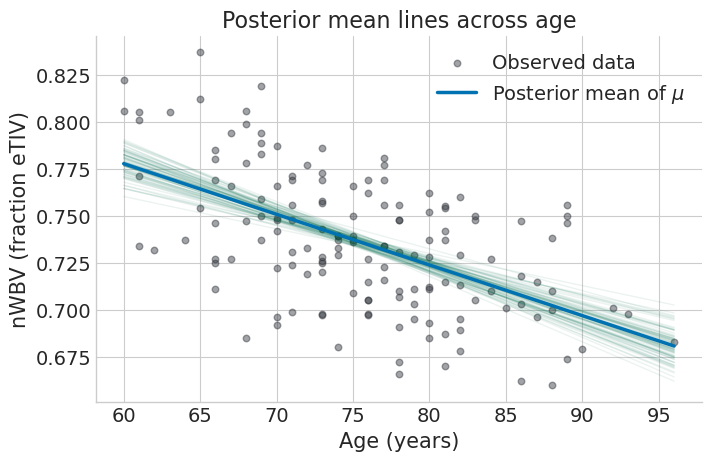

In [226]:
line_draw_count = 80
line_rng = np.random.default_rng(RANDOM_SEED)
line_indices = line_rng.choice(
    np.arange(nwbv_age_beta0.sizes["sample"]),
    size=min(line_draw_count, nwbv_age_beta0.sizes["sample"]),
    replace=False,
)

age_grid_da = xr.DataArray(
    age_grid,
    dims="obs_id",
    coords={"obs_id": np.arange(len(age_grid))},
)
mu_lines = nwbv_age_beta0 + nwbv_age_beta1 * age_grid_da

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(simple_df["Age"], simple_df["nWBV"], s=22, color=COLORS["observed"], alpha=0.45, label="Observed data")

for draw_idx in line_indices:
    ax.plot(age_grid, mu_lines.isel(sample=draw_idx), color=COLORS["posterior"], alpha=0.08, lw=1)

ax.plot(age_grid, mu_lines.mean(dim="sample"), color=COLORS["mean"], lw=2.5, label=r"Posterior mean of $\mu$")
style_axis(ax, "Posterior mean lines across age", LABELS["Age"], LABELS["nWBV"])
ax.legend()
plt.show()


### 8.3.20 Our main interest is in the slope

Figure IDs: F15/F16/F17. The same output block also supports slides 8.3.21 and 8.3.22.

In [ ]:
plt.figure(figsize=(7, 4.5))
az.plot_posterior(nwbv_age_idata, var_names=["beta1"])
plt.xlabel("Age slope (fractional nWBV per year)")
plt.title("Posterior distribution of the slope (nWBV / year)")


### 8.3.21 The intercept is nWBV at age 0

The uncentered intercept is an extrapolated quantity, so interpretation waits until the posterior has been sampled and checked.


In [ ]:
plt.figure(figsize=(7, 4.5))
az.plot_posterior(nwbv_age_idata, var_names=["beta0"])
plt.xlabel("Age intercept (fractional nWBV)")
plt.title("Posterior distribution of the intercept (nWBV)")


### 8.3.22 Sigma is the variability among individuals


In [ ]:
plt.figure(figsize=(7, 4.5))
az.plot_posterior(nwbv_age_idata, var_names=["sigma"])
plt.xlabel("Residual SD (fractional nWBV)")
plt.title("Posterior distribution of the residual SD")


### 8.3.23 β₀ and β₁ are strongly inversely correlated

Figure ID: F18.

array([[<Axes: >, None],
       [<Axes: xlabel='beta0', ylabel='beta1'>, <Axes: >]], dtype=object)

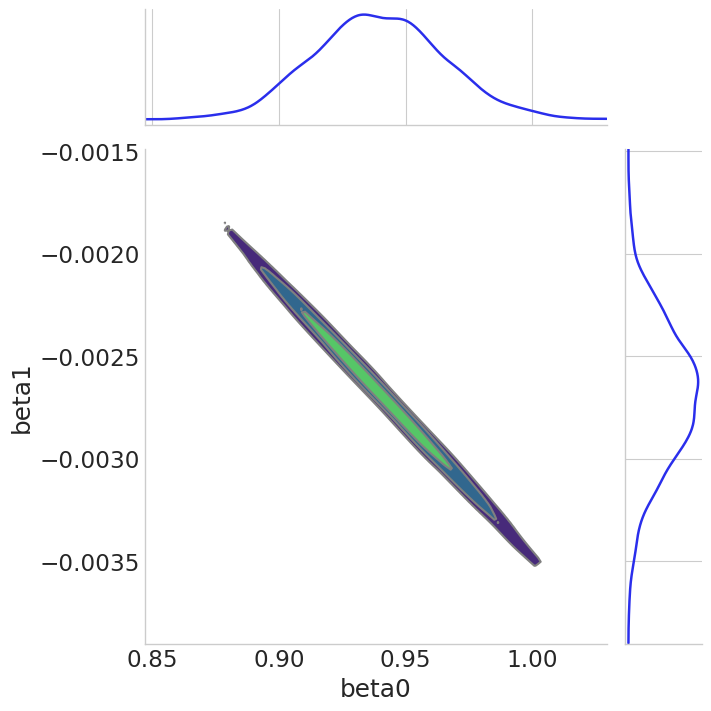

In [168]:
az.plot_pair(
    nwbv_age_idata,
    var_names=["beta0", "beta1"],
    kind="kde",
    marginals=True,
    figsize=(7, 7),
)

Posterior summary supporting slides 8.3.20-8.3.23.

In [169]:
az.hdi(nwbv_age_idata, hdi_prob=0.94)

<xarray.Dataset> Size: 4kB
Dimensions:  (hdi: 2, obs_id: 150)
Coordinates:
  * hdi      (hdi) <U6 48B 'lower' 'higher'
  * obs_id   (obs_id) int64 1kB 0 1 2 3 4 5 6 7 ... 143 144 145 146 147 148 149
Data variables:
    beta0    (hdi) float64 16B 0.892 0.987
    beta1    (hdi) float64 16B -0.003331 -0.002069
    sigma    (hdi) float64 16B 0.0273 0.03393
    mu       (obs_id, hdi) float64 2kB 0.696 0.7134 0.7327 ... 0.7647 0.7852
Attributes:
    created_at:                 2026-06-02T23:25:57.027123+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.1
    sampling_time:              12.12300157546997
    tuning_steps:               1000

### 8.3.24 Raw effect size is the slope

Figure IDs: F19/F20.

<Axes: title={'center': 'beta1'}>

<Figure size 700x450 with 0 Axes>

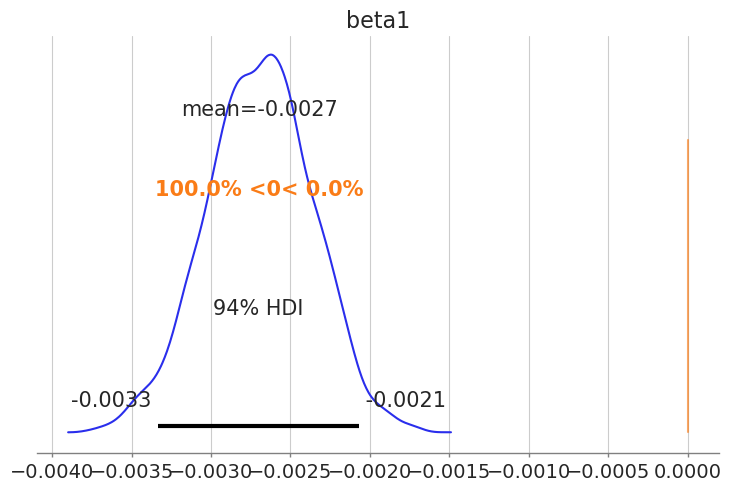

<Figure size 700x450 with 0 Axes>

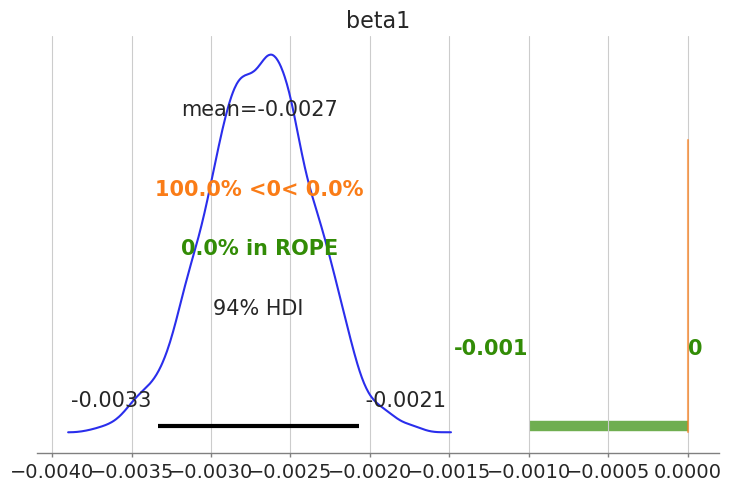

In [170]:
plt.figure(figsize=(7, 4.5))
az.plot_posterior(nwbv_age_idata, var_names=["beta1"], hdi_prob=0.94, ref_val=0)

plt.figure(figsize=(7, 4.5))
az.plot_posterior(nwbv_age_idata, var_names=["beta1"], hdi_prob=0.94, ref_val=0, rope=[-0.001, 0.0])

### 8.3.25 Standardized slope is a standardized effect size

Figure ID: F21.

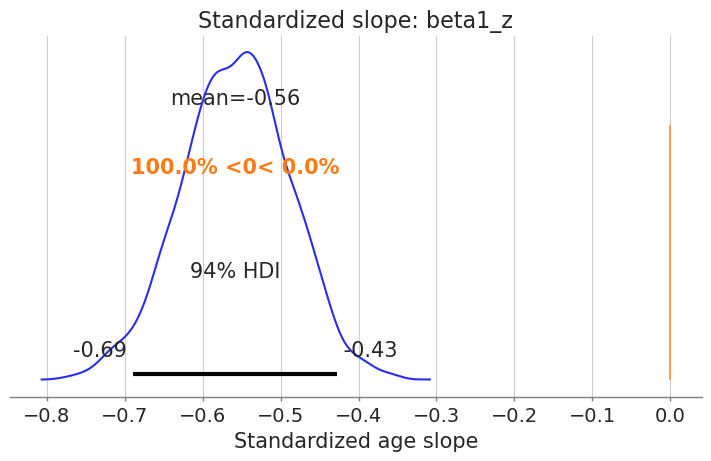

In [171]:
beta1_z = nwbv_age_beta1 * simple_df["Age"].std(ddof=1) / simple_df["nWBV"].std(ddof=1)

fig, ax = plt.subplots(figsize=(7, 4.5))
az.plot_posterior(beta1_z, hdi_prob=0.94, ref_val=0, ax=ax)
ax.set_xlabel("Standardized age slope")
ax.set_title("Standardized slope: beta1_z")
plt.show()


<a id="section-84"></a>
## 8.4 Centered and uncentered data
Centering changes the coordinate system for the predictor. The fitted mean is unchanged, the intercept becomes local, prior specification becomes more natural, and posterior geometry improves.

### 8.4.27 Centering and standardization remove means and units
These cells repeat the simple-regression workflow with `Age_c_data`, so `beta0` is the expected fractional nWBV at the mean observed age rather than an extrapolated age-0 intercept.

### 8.4.30 Prior for β₀ will be centered at the mean nWBV

This cell is placed before the centered model is built because project conventions keep prior constants before model-building cells.

With centered age, `beta0` is the expected fractional nWBV for a person at the mean observed age. The intercept prior can therefore be local and tight around the observed nWBV scale, while the slope prior remains in nWBV units per year.

In [172]:
age_c_data = simple_df["Age_c"].astype(float)

mu_0_centered = nwbv_data.mean()
sigma_0_centered = 0.05
mu_1_centered = -0.002
sigma_1_centered = 0.003
sigma_sigma_centered = 0.04

centered_priors_df = pd.DataFrame(
    {
        "Parameter": ["Intercept at mean Age (mu_0)", "Age_c slope (mu_1)", "Residual SD (sigma)"],
        "Distribution": ["Normal", "Normal", "Half-Normal"],
        "Parameters": [
            f"mu={mu_0_centered:.3f}, sigma={sigma_0_centered:.3f}",
            f"mu={mu_1_centered:.3f}, sigma={sigma_1_centered:.3f}",
            f"sigma={sigma_sigma_centered:.3f}",
        ],
    }
)

display(pretty_table(centered_priors_df, "Table 8.3A: Prior specifications for the centered simple linear regression model", hide_index=False))


,Parameter,Distribution,Parameters
0,Intercept at mean Age (mu_0),Normal,"mu=0.736, sigma=0.050"
1,Age_c slope (mu_1),Normal,"mu=-0.002, sigma=0.003"
2,Residual SD (sigma),Half-Normal,sigma=0.040


### 8.4.28 Switch the model to use a centered independent variable

Figure ID: F23.

In [173]:
coords_age_centered = {"obs_id": np.arange(len(simple_df))}

with pm.Model(coords=coords_age_centered) as nwbv_age_centered_model:
    Age_c_data = pm.Data("Age_c_data", age_c_data, dims="obs_id")
    beta0 = pm.Normal("beta0", mu=mu_0_centered, sigma=sigma_0_centered)
    beta1 = pm.Normal("beta1", mu=mu_1_centered, sigma=sigma_1_centered)
    sigma = pm.HalfNormal("sigma", sigma=sigma_sigma_centered)
    mu = pm.Deterministic("mu", beta0 + beta1 * Age_c_data, dims="obs_id")
    nwbv_obs = pm.Normal("nwbv_obs", mu=mu, sigma=sigma, observed=nwbv_data, dims="obs_id")


For slide 8.4.28: Switch the model to use a centered independent variable.

Graphical sanity check for the centered PyMC model.

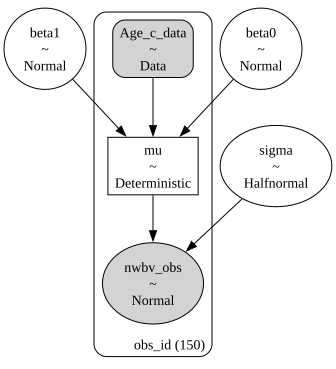

In [174]:
try:
    display(pm.model_to_graphviz(nwbv_age_centered_model, var_names=["beta0", "beta1", "sigma", "Age_c_data", "mu", "nwbv_obs"]))
except Exception as exc:
    print("Graphviz is not available in this environment.")
    print(nwbv_age_centered_model)
    print(exc)


For slide 8.4.30: Prior for β₀ will be centered at the mean nWBV.

Prior predictive check for the centered parameterization.

Sampling: [beta0, beta1, nwbv_obs, sigma]


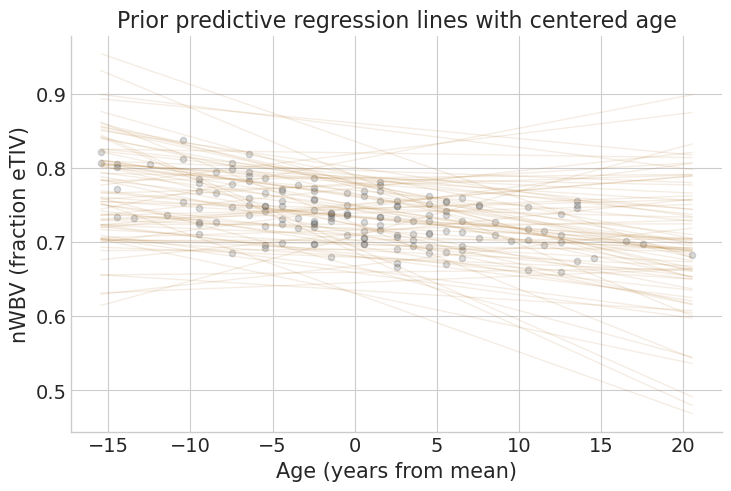

In [175]:
with nwbv_age_centered_model:
    nwbv_age_centered_prior = pm.sample_prior_predictive(samples=prior_predictive_samples, random_seed=RANDOM_SEED)

prior_beta0_centered = nwbv_age_centered_prior.prior["beta0"].values.reshape(-1)
prior_beta1_centered = nwbv_age_centered_prior.prior["beta1"].values.reshape(-1)

fig, ax = plt.subplots()
ax.scatter(simple_df["Age_c"], simple_df["nWBV"], s=20, color=COLORS["observed"], alpha=0.18)
for idx in rng.choice(prior_beta0_centered.size, size=80, replace=False):
    ax.plot(age_grid_c, prior_beta0_centered[idx] + prior_beta1_centered[idx] * age_grid_c, color=COLORS["prior"], alpha=0.11, lw=1)
style_axis(ax, "Prior predictive regression lines with centered age", LABELS["Age_c"], LABELS["nWBV"])
plt.show()


### 8.4.31 Intercept has different meaning in the two models

Figure ID: F26. This figure is computed after the uncentered Age model has been sampled, so the fitted line and derived average-age value are posterior-derived.

C:\Users\User\AppData\Local\Temp\ipykernel_33264\1376478566.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


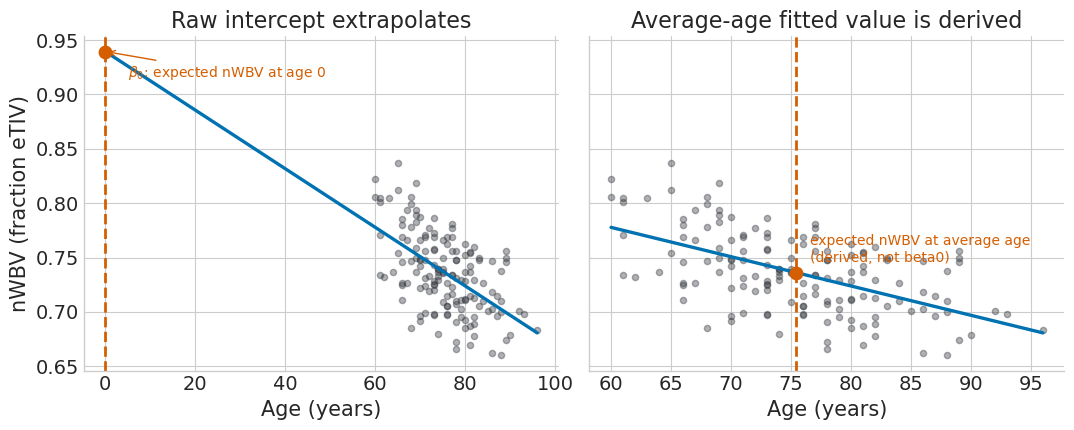

In [229]:
posterior_beta0_age = nwbv_age_beta0.mean(dim="sample").item()
posterior_beta1_age = nwbv_age_beta1.mean(dim="sample").item()
age_zero_grid = np.linspace(0, simple_df["Age"].max(), 250)
line_zero = posterior_beta0_age + posterior_beta1_age * age_zero_grid
mean_age = simple_df["Age"].mean()
mean_nwbv = posterior_beta0_age + posterior_beta1_age * mean_age
line_observed_age = posterior_beta0_age + posterior_beta1_age * age_grid

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
axes[0].scatter(simple_df["Age"], simple_df["nWBV"], s=20, color=COLORS["observed"], alpha=0.38)
axes[0].plot(age_zero_grid, line_zero, color=COLORS["mean"], lw=2.4)
axes[0].axvline(0, color=COLORS["reference"], ls="--", lw=2)
axes[0].scatter([0], [posterior_beta0_age], color=COLORS["reference"], s=80, zorder=5)
axes[0].annotate(
    r"$\beta_0$: expected nWBV at age 0",
    xy=(0, posterior_beta0_age),
    xytext=(16, -18),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": COLORS["reference"]},
    color=COLORS["reference"],
)
style_axis(axes[0], "Raw intercept extrapolates", LABELS["Age"], LABELS["nWBV"])

axes[1].scatter(simple_df["Age"], simple_df["nWBV"], s=20, color=COLORS["observed"], alpha=0.38)
axes[1].plot(age_grid, line_observed_age, color=COLORS["mean"], lw=2.4)
axes[1].axvline(mean_age, color=COLORS["reference"], ls="--", lw=2)
axes[1].scatter([mean_age], [mean_nwbv], color=COLORS["reference"], s=80, zorder=5)
axes[1].annotate(
    "expected nWBV at average age\n(derived, not beta0)",
    xy=(mean_age, mean_nwbv),
    xytext=(10, 8),
    textcoords="offset points",
    color=COLORS["reference"],
)
style_axis(axes[1], "Average-age fitted value is derived", LABELS["Age"], "")
plt.tight_layout()
plt.show()


### 8.4.32 The sampling is slower and less independent

In [178]:
with nwbv_age_centered_model:
    nwbv_age_centered_idata = pm.sample(
        draws=posterior_draws,
        tune=posterior_tune,
        chains=posterior_chains,
        cores=1,
        target_accept=target_accept,
        random_seed=RANDOM_SEED,
        progressbar=False,
    )
    pm.sample_posterior_predictive(
        nwbv_age_centered_idata,
        random_seed=RANDOM_SEED,
        progressbar=False,
        extend_inferencedata=True,
    )


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [beta0, beta1, sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
Sampling: [nwbv_obs]


For slide 8.4.32: The sampling is slower and less independent.

Figure ID: F27.

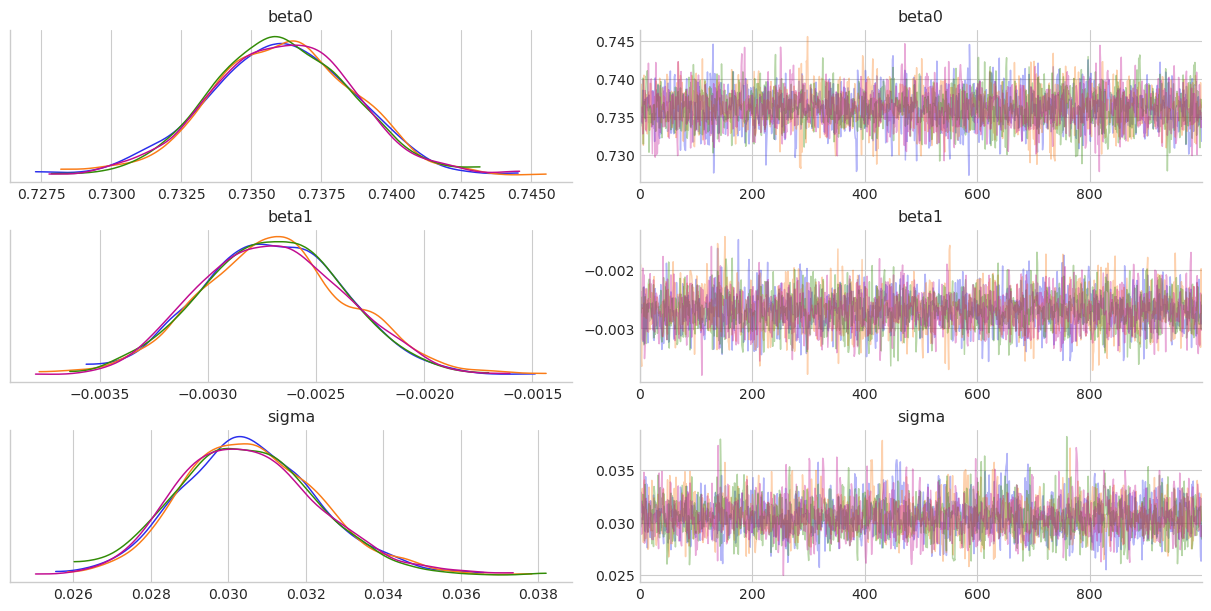

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta0,0.736,0.003,0.731,0.741,0.0,0.0,3920.0,2673.0,1.0
beta1,-0.003,0.000,-0.003,-0.002,0.0,0.0,3759.0,2793.0,1.0
sigma,0.031,0.002,0.027,0.034,0.0,0.0,3430.0,2605.0,1.0


In [179]:
az.plot_trace(nwbv_age_centered_idata, var_names=["beta0", "beta1", "sigma"], compact=False)
plt.show()
az.summary(nwbv_age_centered_idata, var_names=["beta0", "beta1", "sigma"])


For slide 8.4.32: The sampling is slower and less independent.

Diagnostics table comparing the two parameterizations.

In [180]:
diagnostic_rows = []
for label, idata in [
    ("nWBV ~ Age", nwbv_age_idata),
    ("nWBV ~ Age_c", nwbv_age_centered_idata),
]:
    summary = az.summary(idata, var_names=["beta0", "beta1", "sigma"])
    divergences = int(idata.sample_stats["diverging"].sum())
    for parameter in ["beta0", "beta1", "sigma"]:
        diagnostic_rows.append(
            {
                "Model": label,
                "Parameter": parameter,
                "ess_bulk": summary.loc[parameter, "ess_bulk"],
                "ess_tail": summary.loc[parameter, "ess_tail"],
                "r_hat": summary.loc[parameter, "r_hat"],
                "divergences": divergences,
            }
        )

diagnostic_comparison = pd.DataFrame(diagnostic_rows)
display(
    pretty_table(
        diagnostic_comparison,
        "Table 8.4A: Sampling diagnostics before and after centering",
        formats={"ess_bulk": fixed_decimals(0), "ess_tail": fixed_decimals(0), "r_hat": fixed_decimals(3)},
    )
)


Model,Parameter,ess_bulk,ess_tail,r_hat,divergences
nWBV ~ Age,beta0,1215,1578,1.000,0
nWBV ~ Age,beta1,1229,1646,1.000,0
nWBV ~ Age,sigma,1776,1674,1.000,0
nWBV ~ Age_c,beta0,3920,2673,1.000,0
nWBV ~ Age_c,beta1,3759,2793,1.000,0
nWBV ~ Age_c,sigma,3430,2605,1.000,0


For slide 8.4.32: The sampling is slower and less independent.

Posterior predictive check before interpreting centered parameters.

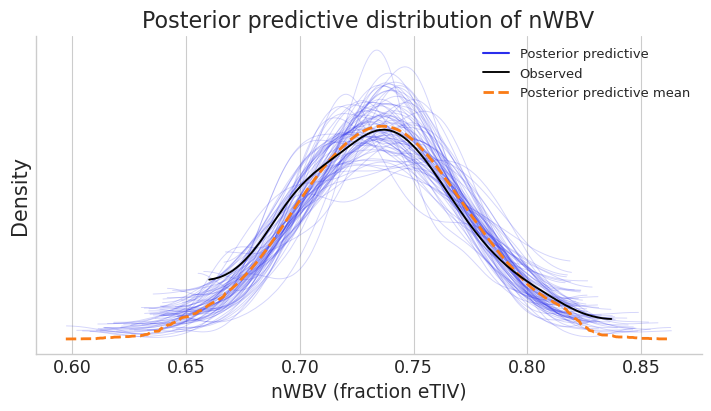

In [181]:
ax = az.plot_ppc(
    nwbv_age_centered_idata,
    var_names=["nwbv_obs"],
    num_pp_samples=80,
    kind="kde",
    figsize=(7, 4),
)
ax.set_title("Posterior predictive distribution of nWBV")
ax.set_xlabel(LABELS["nWBV"])
ax.set_ylabel("Density")
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_33264\4133558971.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


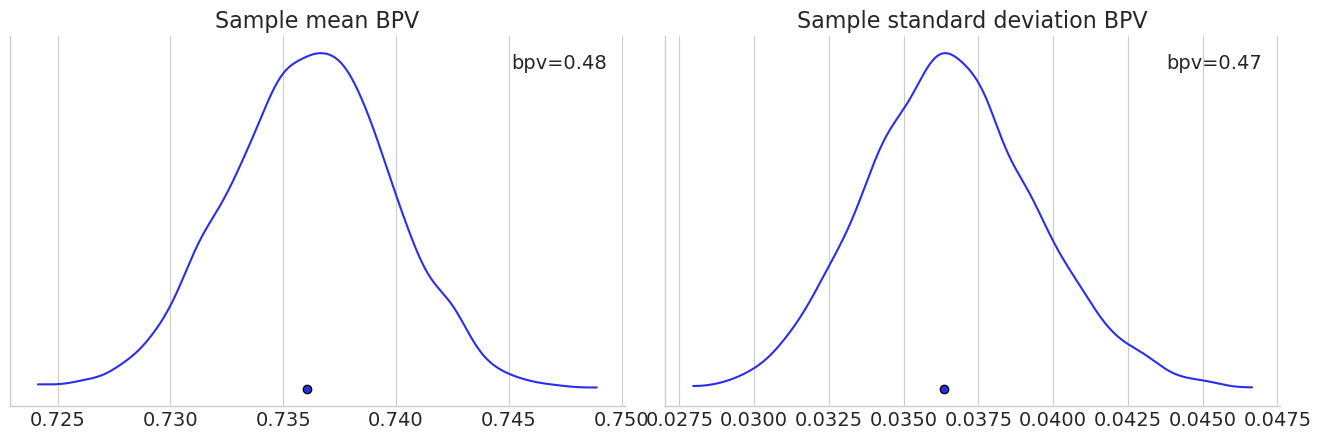

In [182]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

az.plot_bpv(
    nwbv_age_centered_idata,
    var_names=["nwbv_obs"],
    kind="t_stat",
    t_stat="mean",
    ax=ax[0],
)

az.plot_bpv(
    nwbv_age_centered_idata,
    var_names=["nwbv_obs"],
    kind="t_stat",
    t_stat="std",
    ax=ax[1],
)

ax[0].set_title("Sample mean BPV")
ax[1].set_title("Sample standard deviation BPV")
plt.tight_layout()


For slide 8.4.32: The sampling is slower and less independent.

Prediction workflow for the centered model; later slides reuse these posterior-derived quantities.

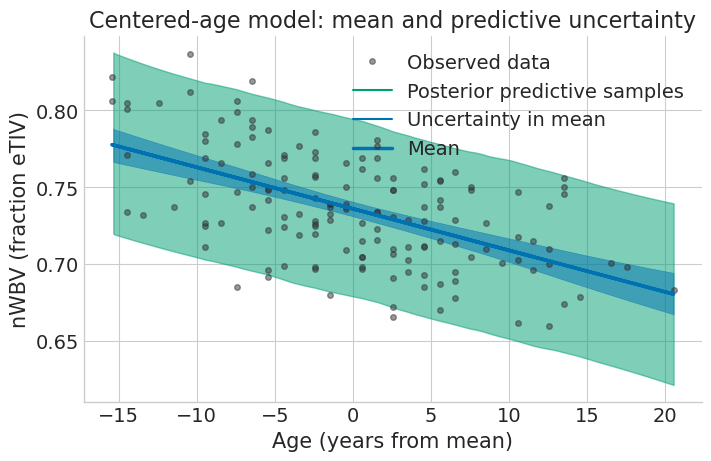

In [230]:
nwbv_age_centered_beta0 = nwbv_age_centered_idata.posterior["beta0"].stack(sample=("chain", "draw"))
nwbv_age_centered_beta1 = nwbv_age_centered_idata.posterior["beta1"].stack(sample=("chain", "draw"))
nwbv_age_centered_sigma = nwbv_age_centered_idata.posterior["sigma"].stack(sample=("chain", "draw"))

with az.rc_context({"stats.ci_prob": 0.94}):
    axes = az.plot_lm(
        y="nwbv_obs",
        x="Age_c_data",
        y_model="mu",
        y_hat="nwbv_obs",
        idata=nwbv_age_centered_idata,
        kind_pp="hdi",
        kind_model="hdi",
        figsize=(7, 4.5),
        y_kwargs={
            "color": COLORS["observed"],
            "marker": "o",
            "markersize": 4,
            "linewidth": 0,
            "alpha": 0.5,
            "label": "Observed data",
        },
        y_hat_fill_kwargs={"color": COLORS["predictive"]},
        y_model_fill_kwargs={"color": COLORS["mean"]},
        y_model_mean_kwargs={"color": COLORS["mean"], "linewidth": 2.5},
        show=False,
    )

ax = axes[0, 0]
ax.set_xlabel(LABELS["Age_c"])
ax.set_ylabel(LABELS["nWBV"])
ax.set_title("Centered-age model: mean and predictive uncertainty")
ax.legend(loc="best")
plt.show()


### 8.4.29 The fit will be the same

Figure ID: F24. This figure supports slide 8.4.29, but it is generated here after both models have been fit.

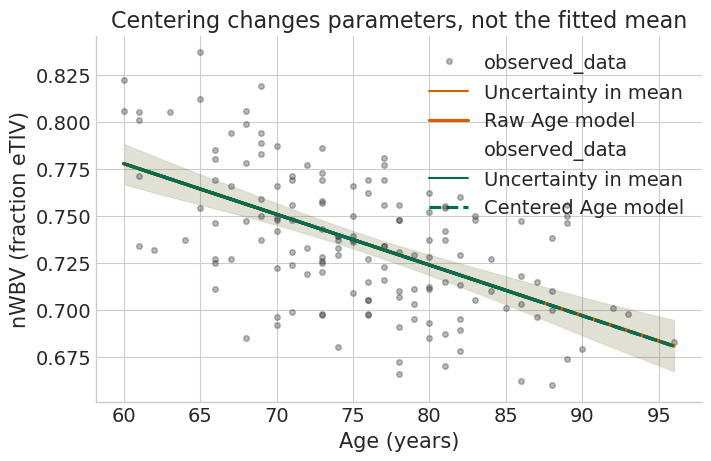

Maximum absolute difference between posterior mean lines on observed data: `9.958e-05` nWBV units.

In [235]:
fig, ax = plt.subplots(figsize=(7, 4.5))
with az.rc_context({"stats.ci_prob": 0.94}):
    az.plot_lm(
        y=nwbv_age_idata.observed_data["nwbv_obs"],
        x=nwbv_age_idata.constant_data["Age_data"],
        y_model="mu",
        idata=nwbv_age_idata,
        kind_model="hdi",
        y_kwargs={
            "color": COLORS["observed"],
            "marker": "o",
            "markersize": 4,
            "linewidth": 0,
            "alpha": 0.35,
        },
        y_model_fill_kwargs={"color": COLORS["age"], "alpha": 0.10},
        y_model_mean_kwargs={"color": COLORS["age"], "linewidth": 2.3},
        axes=ax,
        show=False,
    )
    az.plot_lm(
        y=nwbv_age_centered_idata.observed_data["nwbv_obs"],
        x=simple_df["Age"].to_numpy(),
        y_model="mu",
        idata=nwbv_age_centered_idata,
        kind_model="hdi",
        y_kwargs={"alpha": 0},
        y_model_fill_kwargs={"color": COLORS["posterior"], "alpha": 0.10},
        y_model_mean_kwargs={"color": COLORS["posterior"], "linewidth": 2.3, "linestyle": "--"},
        axes=ax,
        show=False,
    )
style_axis(ax, "Centering changes parameters, not the fitted mean", LABELS["Age"], LABELS["nWBV"])
handles, labels = ax.get_legend_handles_labels()
labels = ["Raw Age model" if label == "Mean" else label for label in labels]
if "Mean" in labels:
    labels[labels.index("Mean")] = "Raw Age model"
# The second plot_lm call also labels its mean as "Mean" internally.
if len(labels) >= 2:
    labels[-1] = "Centered Age model"
ax.legend(handles, labels, loc="best")
plt.show()

raw_mu_mean = nwbv_age_idata.posterior["mu"].mean(dim=("chain", "draw"))
centered_mu_mean = nwbv_age_centered_idata.posterior["mu"].mean(dim=("chain", "draw"))
fit_difference = np.abs(raw_mu_mean - centered_mu_mean).max().item()
display(Markdown(f"Maximum absolute difference between posterior mean lines on observed data: `{fit_difference:.4g}` nWBV units."))


### 8.4.33 The posterior of the slope is unchanged

Figure ID: F28.

In [ ]:
plt.figure(figsize=(7, 4.5))
az.plot_posterior(nwbv_age_centered_idata, var_names=["beta1"])
plt.xlabel("Age_c slope (fractional nWBV per year)")
plt.title("Posterior distribution of the centered-age slope (nWBV / year)")


### 8.4.34 The posterior of the intercept is different


In [ ]:
plt.figure(figsize=(7, 4.5))
az.plot_posterior(nwbv_age_centered_idata, var_names=["beta0"])
plt.xlabel("Mean-age intercept (fractional nWBV)")
plt.title("Posterior distribution of the intercept at mean age")


In [187]:
az.hdi(nwbv_age_centered_idata, hdi_prob=0.94)


<xarray.Dataset> Size: 4kB
Dimensions:  (hdi: 2, obs_id: 150)
Coordinates:
  * hdi      (hdi) <U6 48B 'lower' 'higher'
  * obs_id   (obs_id) int64 1kB 0 1 2 3 4 5 6 7 ... 143 144 145 146 147 148 149
Data variables:
    beta0    (hdi) float64 16B 0.7313 0.7407
    beta1    (hdi) float64 16B -0.003324 -0.002086
    sigma    (hdi) float64 16B 0.02714 0.03379
    mu       (obs_id, hdi) float64 2kB 0.6966 0.7135 0.7324 ... 0.7646 0.785
Attributes:
    created_at:                 2026-06-02T23:26:04.964686+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.1
    sampling_time:              3.779326915740967
    tuning_steps:               1000

### 8.4.35 The final fit is the same


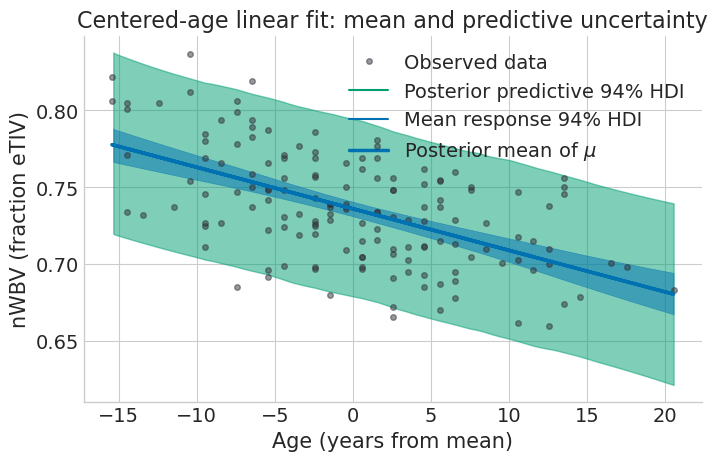

In [188]:
with az.rc_context({"stats.ci_prob": 0.94}):
    axes = az.plot_lm(
        y="nwbv_obs",
        x="Age_c_data",
        y_model="mu",
        y_hat="nwbv_obs",
        idata=nwbv_age_centered_idata,
        kind_pp="hdi",
        kind_model="hdi",
        figsize=(7, 4.5),
        y_kwargs={
            "color": COLORS["observed"],
            "marker": "o",
            "markersize": 4,
            "linewidth": 0,
            "alpha": 0.5,
            "label": "Observed data",
        },
        y_hat_fill_kwargs={"color": COLORS["predictive"]},
        y_model_fill_kwargs={"color": COLORS["mean"]},
        y_model_mean_kwargs={"color": COLORS["mean"], "linewidth": 2.5},
        show=False,
    )

ax = axes[0, 0]
ax.set_xlabel(LABELS["Age_c"])
ax.set_ylabel(LABELS["nWBV"])
ax.set_title("Centered-age linear fit: mean and predictive uncertainty")

handles, labels = ax.get_legend_handles_labels()
legend_labels = {
    "Posterior predictive samples": "Posterior predictive 94% HDI",
    "Uncertainty in mean": "Mean response 94% HDI",
    "Mean": r"Posterior mean of $\mu$",
}
ax.legend(handles, [legend_labels.get(label, label) for label in labels], loc="best")
plt.show()


<a id="section-85"></a>
## 8.5 Multivariate regression
Multivariate dependencies, the multivariate model with simple and matrix variables, and Bayesian workflow.


### 8.5.37 Mini-mental state exam (MMSE)

MMSE is bounded and ceiling-limited. In this lecture it is a predictor, not a Gaussian outcome.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.0))
ax.hist(
    mmse_simple_df["MMSE"],
    bins=np.arange(mmse_simple_df["MMSE"].min() - 0.5, mmse_simple_df["MMSE"].max() + 1.5),
    color=COLORS["light"],
    edgecolor="white",
)
style_axis(ax, "MMSE is bounded and ceiling-heavy", LABELS["MMSE"], "Count")
plt.show()


### 8.5.38 MMSE predicts brain volume

Raw descriptive scatter only; no fitted line is used before the multiple-regression model exists.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.0))
ax.scatter(mmse_simple_df["MMSE"], mmse_simple_df["nWBV"], s=30, color=COLORS["observed"], alpha=0.62)
style_axis(ax, "MMSE as a predictor of nWBV", LABELS["MMSE"], LABELS["nWBV"])
plt.show()


### 8.5.39 Can we ask about Age and MMSE together?

Figure ID: F41. This is descriptive raw data only: no fitted lines, smoothers, correlations, or p-values.


C:\Users\User\AppData\Local\Temp\ipykernel_33264\3970599194.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


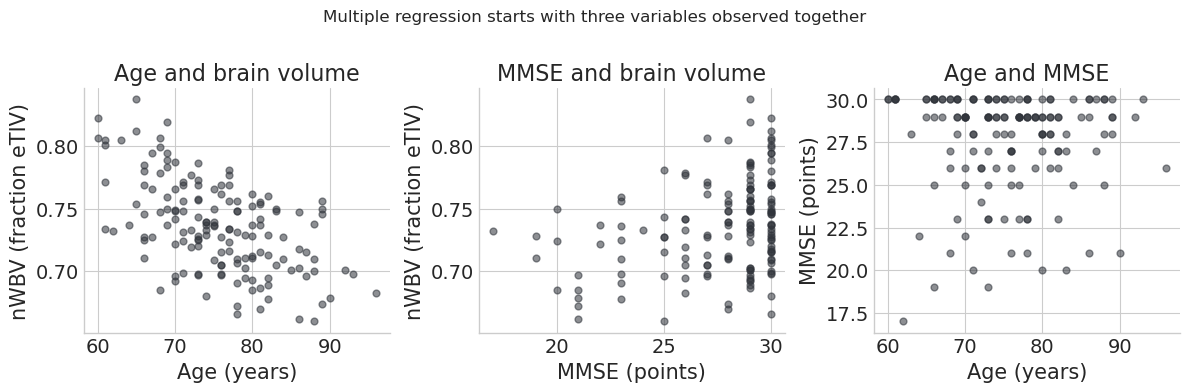

In [196]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))

raw_panels = [
    (axes[0], "Age", "nWBV", "Age and brain volume"),
    (axes[1], "MMSE", "nWBV", "MMSE and brain volume"),
    (axes[2], "Age", "MMSE", "Age and MMSE"),
]

for ax, x_var, y_var, title in raw_panels:
    ax.scatter(
        multiple_df[x_var],
        multiple_df[y_var],
        s=24,
        alpha=0.55,
        color=COLORS["observed"],
    )
    style_axis(ax, title, LABELS.get(x_var, x_var), LABELS.get(y_var, y_var))

fig.suptitle("Multiple regression starts with three variables observed together", y=1.02)
plt.tight_layout()
plt.show()


### 8.5.40 Three dimensional plots can help visualize

These figures use only raw data. They do not add fitted lines, smoothers, correlations, or model summaries.


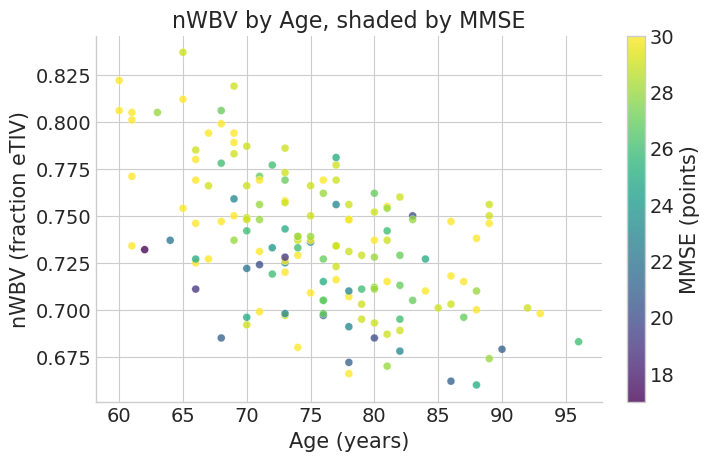

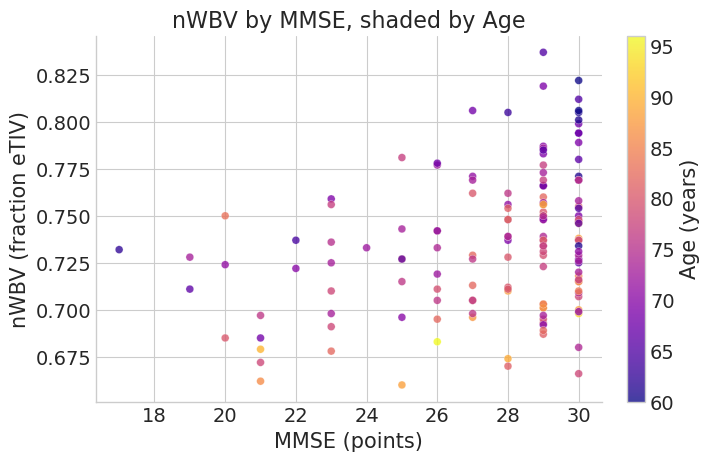

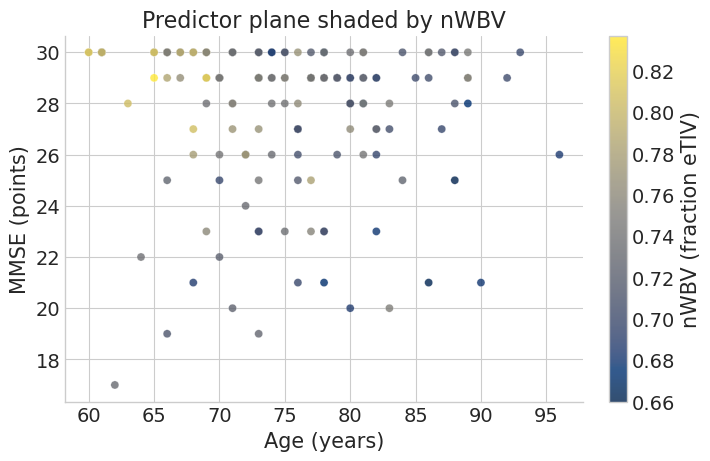

C:\Users\User\AppData\Local\Temp\ipykernel_33264\1391353128.py:70: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


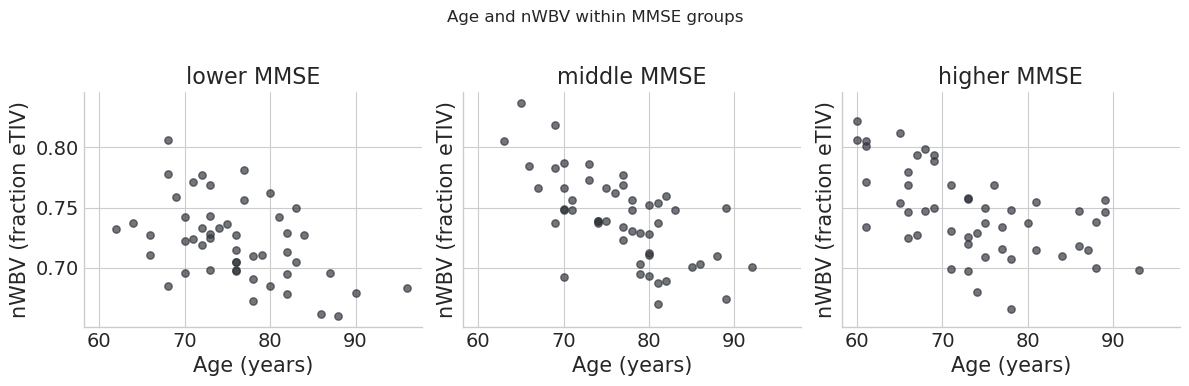

C:\Users\User\AppData\Local\Temp\ipykernel_33264\1391353128.py:79: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


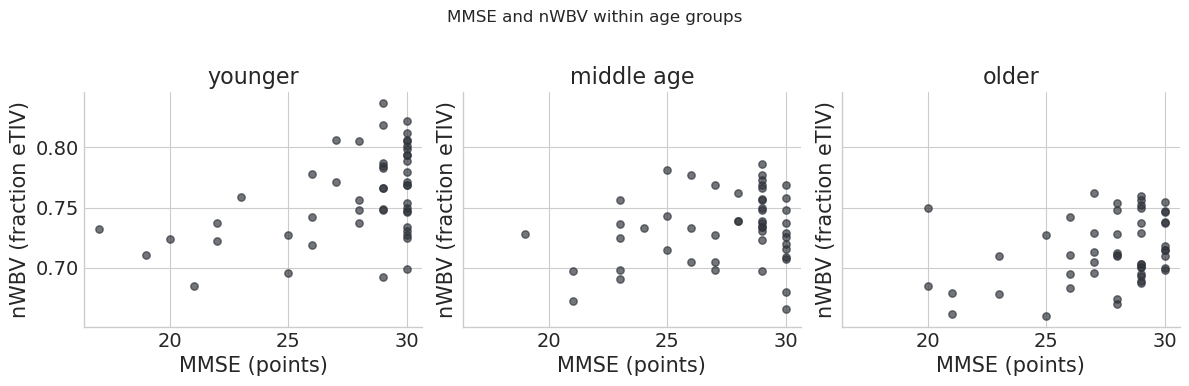

In [194]:
three_var_scatter_df = multiple_df[["Age", "MMSE", "nWBV"]].dropna().copy()
three_var_scatter_df["MMSE_group"] = pd.qcut(
    three_var_scatter_df["MMSE"].rank(method="first"),
    q=3,
    labels=["lower MMSE", "middle MMSE", "higher MMSE"],
)
three_var_scatter_df["Age_group"] = pd.qcut(
    three_var_scatter_df["Age"].rank(method="first"),
    q=3,
    labels=["younger", "middle age", "older"],
)

# Age on x, nWBV on y, MMSE as color.
fig, ax = plt.subplots(figsize=(7, 4.5))
points = ax.scatter(
    three_var_scatter_df["Age"],
    three_var_scatter_df["nWBV"],
    c=three_var_scatter_df["MMSE"],
    cmap="viridis",
    s=32,
    alpha=0.78,
    edgecolor="white",
    linewidth=0.25,
)
style_axis(ax, "nWBV by Age, shaded by MMSE", LABELS["Age"], LABELS["nWBV"])
cbar = fig.colorbar(points, ax=ax)
cbar.set_label(LABELS["MMSE"])
plt.show()

# MMSE on x, nWBV on y, Age as color.
fig, ax = plt.subplots(figsize=(7, 4.5))
points = ax.scatter(
    three_var_scatter_df["MMSE"],
    three_var_scatter_df["nWBV"],
    c=three_var_scatter_df["Age"],
    cmap="plasma",
    s=32,
    alpha=0.78,
    edgecolor="white",
    linewidth=0.25,
)
style_axis(ax, "nWBV by MMSE, shaded by Age", LABELS["MMSE"], LABELS["nWBV"])
cbar = fig.colorbar(points, ax=ax)
cbar.set_label(LABELS["Age"])
plt.show()

# Predictor plane: Age and MMSE define location; nWBV is encoded by color.
fig, ax = plt.subplots(figsize=(7, 4.5))
points = ax.scatter(
    three_var_scatter_df["Age"],
    three_var_scatter_df["MMSE"],
    c=three_var_scatter_df["nWBV"],
    cmap="cividis",
    s=34,
    alpha=0.8,
    edgecolor="white",
    linewidth=0.25,
)
style_axis(ax, "Predictor plane shaded by nWBV", LABELS["Age"], LABELS["MMSE"])
cbar = fig.colorbar(points, ax=ax)
cbar.set_label(LABELS["nWBV"])
plt.show()

# Age/nWBV relationship shown separately for lower, middle, and higher MMSE groups.
fig, axes = plt.subplots(1, 3, figsize=(12, 3.7), sharex=True, sharey=True)
for ax, (group_name, group_df) in zip(axes, three_var_scatter_df.groupby("MMSE_group", observed=True)):
    ax.scatter(group_df["Age"], group_df["nWBV"], s=28, alpha=0.68, color=COLORS["observed"])
    style_axis(ax, str(group_name), LABELS["Age"], LABELS["nWBV"])
fig.suptitle("Age and nWBV within MMSE groups", y=1.03)
plt.tight_layout()
plt.show()

# MMSE/nWBV relationship shown separately for younger, middle-age, and older groups.
fig, axes = plt.subplots(1, 3, figsize=(12, 3.7), sharex=True, sharey=True)
for ax, (group_name, group_df) in zip(axes, three_var_scatter_df.groupby("Age_group", observed=True)):
    ax.scatter(group_df["MMSE"], group_df["nWBV"], s=28, alpha=0.68, color=COLORS["observed"])
    style_axis(ax, str(group_name), LABELS["MMSE"], LABELS["nWBV"])
fig.suptitle("MMSE and nWBV within age groups", y=1.03)
plt.tight_layout()
plt.show()


### 8.5.41 We generalize the bivariate model

Prior constants for μᵢ = β₀ + β₁Ageᶜᵢ + β₂MMSEᶜᵢ.


In [198]:
mu_beta0_multiple = multiple_df["nWBV"].mean()
sigma_beta0_multiple = 0.05
mu_beta1_multiple = 0.0
sigma_beta1_multiple = 0.004
mu_beta2_multiple = 0.0
sigma_beta2_multiple = 0.005
sigma_sigma_multiple = 0.03
coords_multiple = {"obs_id": np.arange(len(multiple_df))}


### 8.5.42 And translate it to PyMC

The scalar version makes the two conditional slopes explicit.


In [199]:
with pm.Model(coords=coords_multiple) as model_multiple:
    Age_c_data = pm.Data("Age_c_data", multiple_df["Age_c"].to_numpy(), dims="obs_id")
    MMSE_c_data = pm.Data("MMSE_c_data", multiple_df["MMSE_c"].to_numpy(), dims="obs_id")
    beta0 = pm.Normal("beta0", mu=mu_beta0_multiple, sigma=sigma_beta0_multiple)
    beta1 = pm.Normal("beta1", mu=mu_beta1_multiple, sigma=sigma_beta1_multiple)
    beta2 = pm.Normal("beta2", mu=mu_beta2_multiple, sigma=sigma_beta2_multiple)
    sigma = pm.HalfNormal("sigma", sigma=sigma_sigma_multiple)
    mu = pm.Deterministic("mu", beta0 + beta1 * Age_c_data + beta2 * MMSE_c_data, dims="obs_id")
    nwbv_obs = pm.Normal("nwbv_obs", mu=mu, sigma=sigma, observed=multiple_df["nWBV"].to_numpy(), dims="obs_id")


### 8.5.43 We can generalize to matrix notation

The data matrix has one column for the intercept and one column for each centered predictor.


In [236]:
var_names_matrix = ["intercept", "Age_c", "MMSE_c"]
X_matrix = np.column_stack(
    [
        np.ones(len(multiple_df)),
        multiple_df["Age_c"].to_numpy(),
        multiple_df["MMSE_c"].to_numpy(),
    ]
)
mu_beta_matrix = np.array([mu_beta0_multiple, mu_beta1_multiple, mu_beta2_multiple])
sigma_beta_matrix = np.array([sigma_beta0_multiple, sigma_beta1_multiple, sigma_beta2_multiple])
coords_matrix = {
    "obs_id": np.arange(len(multiple_df)),
    "var": var_names_matrix,
}


### 8.5.44 We can generalize to matrix notation

The matrix version uses a vector β and computes μ with a vector product.


In [237]:
with pm.Model(coords=coords_matrix) as model_matrix:
    X = pm.Data("X", X_matrix, dims=("obs_id", "var"))
    beta = pm.Normal("beta", mu=mu_beta_matrix, sigma=sigma_beta_matrix, dims="var")
    sigma = pm.HalfNormal("sigma", sigma=sigma_sigma_multiple)
    mu = pm.Deterministic("mu", pm.math.dot(X, beta), dims="obs_id")
    nwbv_obs = pm.Normal(
        "nwbv_obs",
        mu=mu,
        sigma=sigma,
        observed=multiple_df["nWBV"].to_numpy(),
        dims="obs_id",
    )

model_matrix


### 8.5.45 The data matrix holds all the independent variables


In [ ]:
matrix_preview = pd.DataFrame(X_matrix[:8], columns=var_names_matrix)
display(pretty_table(matrix_preview, "Table 8.5A: First rows of the multiple-regression design matrix", formats={col: fixed_decimals(3) for col in matrix_preview.columns}))


### 8.5.46 Always do the workflow

Prior predictive checks come before sampling.


Sampling: [beta, nwbv_obs, sigma]


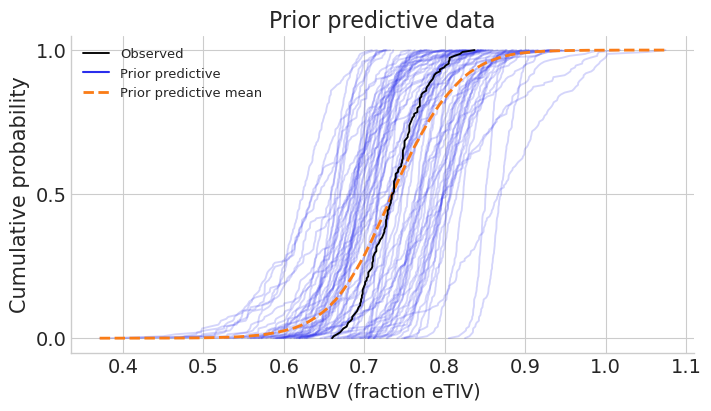

In [204]:
with model_matrix:
    prior_matrix = pm.sample_prior_predictive(samples=prior_predictive_samples, random_seed=RANDOM_SEED)

ax = az.plot_ppc(
    prior_matrix,
    group="prior",
    var_names=["nwbv_obs"],
    num_pp_samples=80,
    kind="cumulative",
    figsize=(7, 4),
    observed=True,
)
ax.set_title("Prior predictive data")
ax.set_xlabel(LABELS["nWBV"])
ax.set_ylabel("Cumulative probability")
plt.show()


### 8.5.47 Check goodness of fit

Sampling diagnostics and posterior predictive checks come before interpreting conditional effects.


In [205]:
with model_matrix:
    idata_matrix = pm.sample(
        draws=posterior_draws,
        tune=posterior_tune,
        chains=posterior_chains,
        target_accept=target_accept,
        random_seed=RANDOM_SEED,
        progressbar=False,
    )
    pm.sample_posterior_predictive(
        idata_matrix,
        random_seed=RANDOM_SEED,
        progressbar=False,
        extend_inferencedata=True,
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 29 seconds.
Sampling: [nwbv_obs]


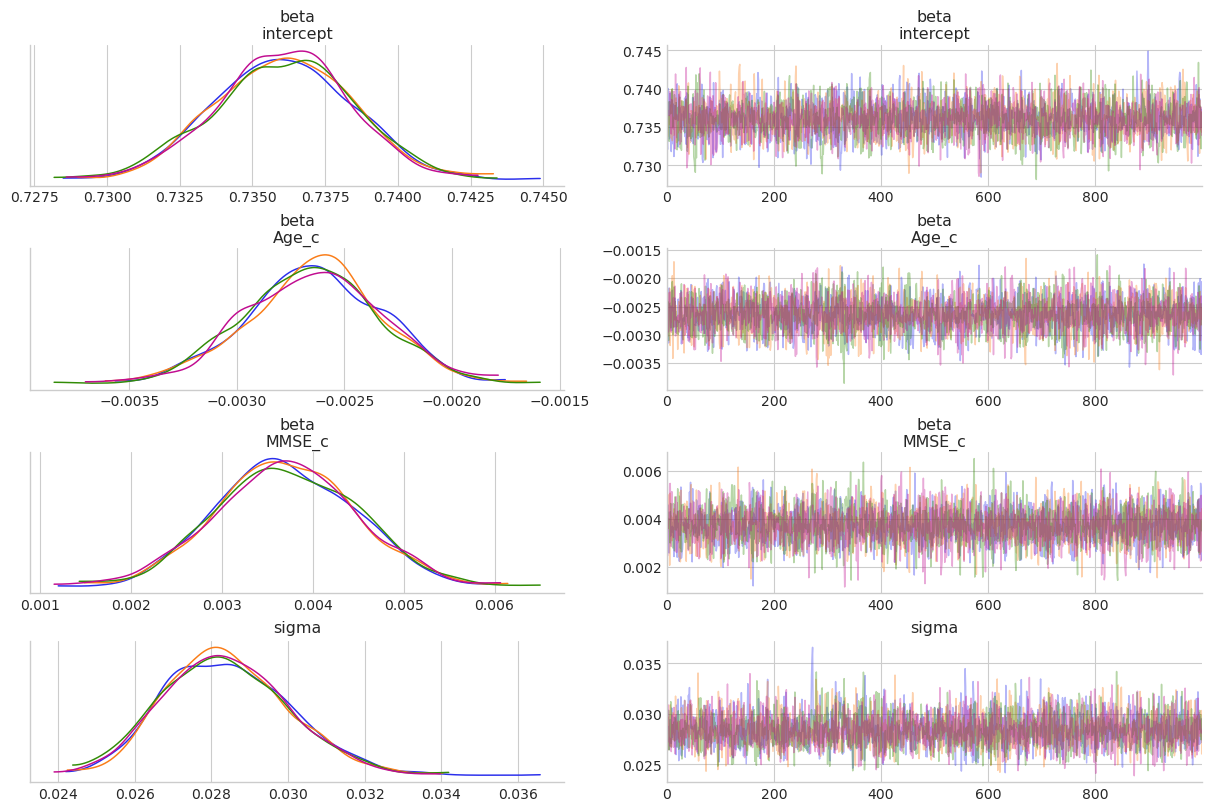

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[intercept],0.736,0.002,0.732,0.740,0.0,0.0,4288.0,2777.0,1.0
beta[Age_c],-0.003,0.000,-0.003,-0.002,0.0,0.0,5362.0,2592.0,1.0
beta[MMSE_c],0.004,0.001,0.002,0.005,0.0,0.0,5582.0,3085.0,1.0
sigma,0.028,0.002,0.025,0.031,0.0,0.0,4650.0,2816.0,1.0


In [206]:
az.plot_trace(idata_matrix, var_names=["beta", "sigma"], compact=False)
plt.show()
az.summary(idata_matrix, var_names=["beta", "sigma"])

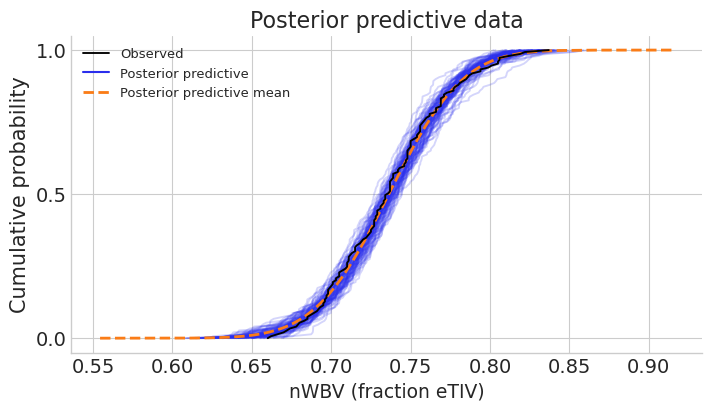

In [207]:
ax = az.plot_ppc(
    idata_matrix,

    var_names=["nwbv_obs"],
    num_pp_samples=80,
    kind="cumulative",
    figsize=(7, 4),
)
ax.set_title("Posterior predictive data")
ax.set_xlabel(LABELS["nWBV"])
ax.set_ylabel("Cumulative probability")
plt.show()


<a id="section-86"></a>
## 8.6 Multivariate regression posterior
The fitted multiple-regression model lets us ask conditional questions: Age while holding MMSE fixed, and MMSE while holding Age fixed.


### 8.6.49 nWBV is reduced around 0.25% / year


Sampling: [nwbv_obs]
Sampling: [nwbv_obs]
Sampling: [nwbv_obs]


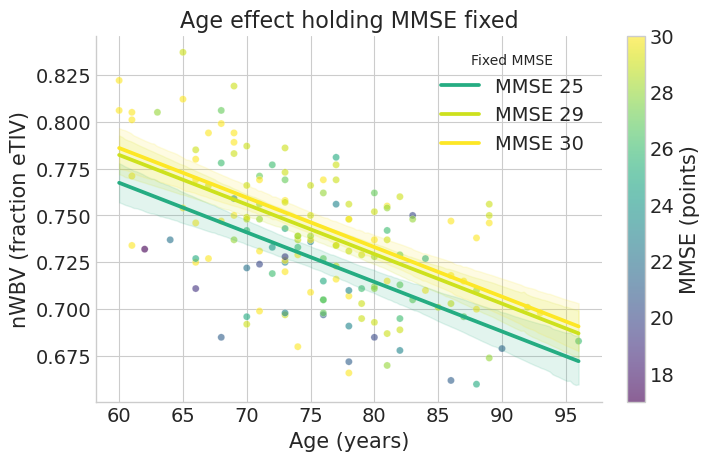

In [208]:
age_grid_m = np.linspace(multiple_df["Age"].min(), multiple_df["Age"].max(), 160)
age_grid_m_c = age_grid_m - multiple_df["Age"].mean()
mmse_values = np.quantile(multiple_df["MMSE"], [0.15, 0.5, 0.85])

matrix_restore_data = {"X": X_matrix}
matrix_restore_coords = {
    "obs_id": np.arange(len(multiple_df)),
    "var": var_names_matrix,
}

mmse_cmap = plt.get_cmap("viridis")
mmse_min = multiple_df["MMSE"].min()
mmse_max = multiple_df["MMSE"].max()

fig, ax = plt.subplots(figsize=(7, 4.5))
points = ax.scatter(
    multiple_df["Age"],
    multiple_df["nWBV"],
    c=multiple_df["MMSE"],
    cmap=mmse_cmap,
    vmin=mmse_min,
    vmax=mmse_max,
    s=26,
    alpha=0.62,
    edgecolor="white",
    linewidth=0.25,
)
for mmse_value in mmse_values:
    mmse_scaled = (mmse_value - mmse_min) / (mmse_max - mmse_min)
    line_color = mmse_cmap(mmse_scaled)
    X_age_slice = np.column_stack(
        [
            np.ones(len(age_grid_m)),
            age_grid_m_c,
            np.full(age_grid_m.shape, mmse_value - multiple_df["MMSE"].mean()),
        ]
    )
    slice_predictions = sample_model_predictions(
        model_matrix,
        idata_matrix,
        data_updates={"X": X_age_slice},
        coords={"obs_id": np.arange(len(age_grid_m)), "var": var_names_matrix},
        restore_data=matrix_restore_data,
        restore_coords=matrix_restore_coords,
    )
    mu_slice = prediction_matrix(slice_predictions, "mu")
    az.plot_hdi(
        age_grid_m,
        mu_slice,
        hdi_prob=0.94,
        color=line_color,
        smooth=False,
        fill_kwargs={"alpha": 0.13},
        ax=ax,
    )
    ax.plot(age_grid_m, mu_slice.mean(axis=0), color=line_color, lw=2.7, label=f"MMSE {mmse_value:.0f}")
style_axis(ax, "Age effect holding MMSE fixed", LABELS["Age"], LABELS["nWBV"])
cbar = fig.colorbar(points, ax=ax)
cbar.set_label(LABELS["MMSE"])
ax.legend(title="Fixed MMSE")
plt.show()


### 8.6.50 nWBV goes up by about 0.4% for every point of MMSE


Sampling: [nwbv_obs]
Sampling: [nwbv_obs]
Sampling: [nwbv_obs]


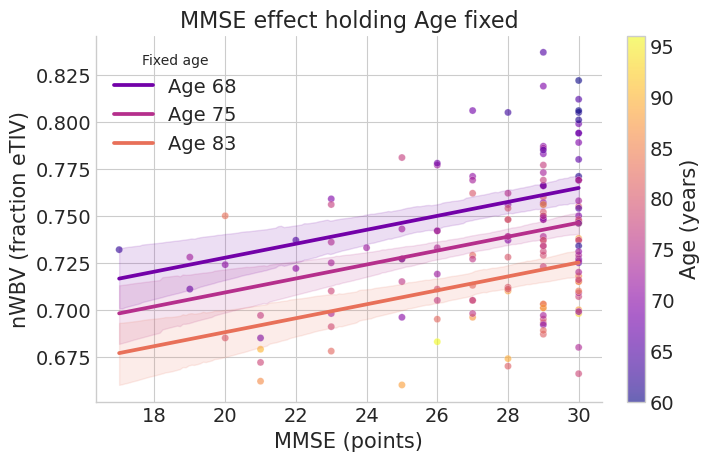

In [209]:
mmse_grid_m = np.linspace(multiple_df["MMSE"].min(), multiple_df["MMSE"].max(), 160)
mmse_grid_m_c = mmse_grid_m - multiple_df["MMSE"].mean()
age_values = np.quantile(multiple_df["Age"], [0.15, 0.5, 0.85])

age_cmap = plt.get_cmap("plasma")
age_min = multiple_df["Age"].min()
age_max = multiple_df["Age"].max()

fig, ax = plt.subplots(figsize=(7, 4.5))
points = ax.scatter(
    multiple_df["MMSE"],
    multiple_df["nWBV"],
    c=multiple_df["Age"],
    cmap=age_cmap,
    vmin=age_min,
    vmax=age_max,
    s=26,
    alpha=0.62,
    edgecolor="white",
    linewidth=0.25,
)
for age_value in age_values:
    age_scaled = (age_value - age_min) / (age_max - age_min)
    line_color = age_cmap(age_scaled)
    X_mmse_slice = np.column_stack(
        [
            np.ones(len(mmse_grid_m)),
            np.full(mmse_grid_m.shape, age_value - multiple_df["Age"].mean()),
            mmse_grid_m_c,
        ]
    )
    slice_predictions = sample_model_predictions(
        model_matrix,
        idata_matrix,
        data_updates={"X": X_mmse_slice},
        coords={"obs_id": np.arange(len(mmse_grid_m)), "var": var_names_matrix},
        restore_data=matrix_restore_data,
        restore_coords=matrix_restore_coords,
    )
    mu_slice = prediction_matrix(slice_predictions, "mu")
    az.plot_hdi(
        mmse_grid_m,
        mu_slice,
        hdi_prob=0.94,
        color=line_color,
        smooth=False,
        fill_kwargs={"alpha": 0.13},
        ax=ax,
    )
    ax.plot(mmse_grid_m, mu_slice.mean(axis=0), color=line_color, lw=2.7, label=f"Age {age_value:.0f}")
style_axis(ax, "MMSE effect holding Age fixed", LABELS["MMSE"], LABELS["nWBV"])
cbar = fig.colorbar(points, ax=ax)
cbar.set_label(LABELS["Age"])
ax.legend(title="Fixed age")
plt.show()


### 8.6.51 The two slope parameters are not correlated


<Axes: xlabel='beta\nAge_c', ylabel='beta\nMMSE_c'>

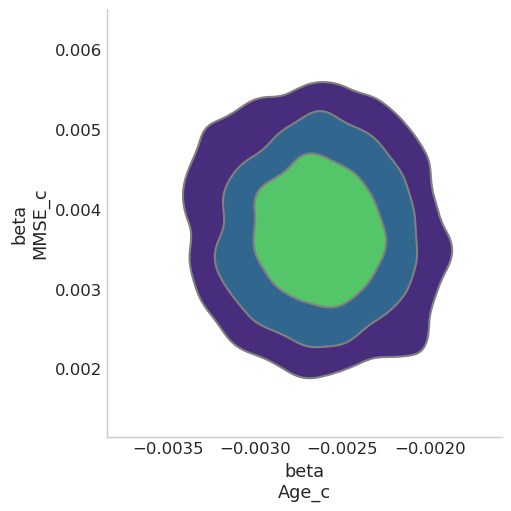

In [251]:
az.plot_pair(
    idata_matrix,
    var_names=["beta"],
    coords={"var": ["Age_c", "MMSE_c"]},
    kind="kde",
    marginals=False,
    figsize=(5, 5),
)

### 8.6.52 Compare effect sizes using standardized slopes


In [ ]:
beta_matrix = idata_matrix.posterior["beta"]
nwbv_sd_multiple = multiple_df["nWBV"].std(ddof=1)
beta_z = xr.concat(
    [
        beta_matrix.sel(var="Age_c") * multiple_df["Age"].std(ddof=1) / nwbv_sd_multiple,
        beta_matrix.sel(var="MMSE_c") * multiple_df["MMSE"].std(ddof=1) / nwbv_sd_multiple,
    ],
    dim=xr.DataArray(["Age", "MMSE"], dims="std_predictor", name="std_predictor"),
)
idata_matrix.posterior["beta_z"] = beta_z

beta_z_age = idata_matrix.posterior["beta_z"].sel(std_predictor="Age")
beta_z_mmse = idata_matrix.posterior["beta_z"].sel(std_predictor="MMSE")

fig, ax = plt.subplots(figsize=(7, 3.8))
az.plot_density(
    [beta_z_age, beta_z_mmse],
    data_labels=["Age", "MMSE"],
    hdi_prob=1.0,
    colors=[COLORS["age"], COLORS["mmse"]],
    ax=ax,
)
add_zero_line(ax)
style_axis(ax, "Standardized conditional slopes", "SD nWBV per SD predictor", "Density")
ax.margins(x=0.08)
set_compact_tick_labels(ax, axis="x", n_ticks=5)
plt.show()


### 8.6.53 Compare HDI and ROPE on standardized effects


Predictor,Raw effect mean,Standardized effect mean,Std. 94% HDI lower,Std. 94% HDI upper,Posterior in ROPE,HDI overlaps ROPE
Age,-0.0026,-0.547,-0.664,-0.429,0.000,no
MMSE,0.0037,0.302,0.192,0.424,0.001,no


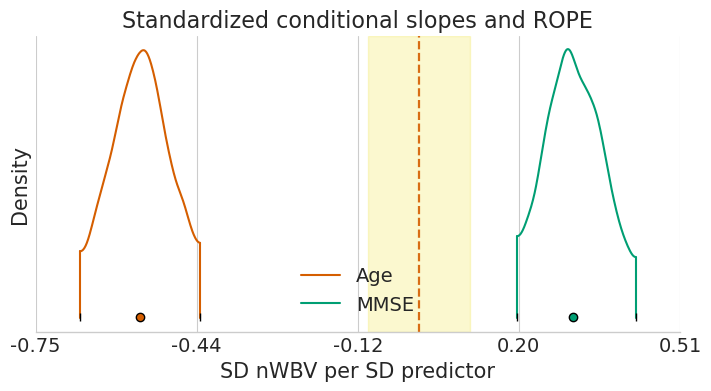

In [256]:
multiple_slope_rope_std = (-0.10, 0.10)

beta_age = idata_matrix.posterior["beta"].sel(var="Age_c")
beta_mmse = idata_matrix.posterior["beta"].sel(var="MMSE_c")
beta_z_age = idata_matrix.posterior["beta_z"].sel(std_predictor="Age")
beta_z_mmse = idata_matrix.posterior["beta_z"].sel(std_predictor="MMSE")

effect_rows = []
for predictor, raw_samples, std_samples in [
    ("Age", beta_age, beta_z_age),
    ("MMSE", beta_mmse, beta_z_mmse),
]:
    std_hdi = az.hdi(std_samples, hdi_prob=0.94).to_array().to_numpy().reshape(-1)
    rope_low, rope_high = multiple_slope_rope_std
    in_rope = ((std_samples >= rope_low) & (std_samples <= rope_high)).mean().item()
    hdi_overlaps_rope = (std_hdi[0] <= rope_high) and (std_hdi[1] >= rope_low)
    effect_rows.append(
        {
            "Predictor": predictor,
            "Raw effect mean": raw_samples.mean().item(),
            "Standardized effect mean": std_samples.mean().item(),
            "Std. 94% HDI lower": std_hdi[0],
            "Std. 94% HDI upper": std_hdi[1],
            "Posterior in ROPE": in_rope,
            "HDI overlaps ROPE": "yes" if hdi_overlaps_rope else "no",
        }
    )

effect_summary_table = pd.DataFrame(effect_rows)
display(
    pretty_table(
        effect_summary_table,
        "Table 8.7A: Raw and standardized conditional effects",
        formats={
            "Raw effect mean": fixed_decimals(4),
            "Standardized effect mean": fixed_decimals(3),
            "Std. 94% HDI lower": fixed_decimals(3),
            "Std. 94% HDI upper": fixed_decimals(3),
            "Posterior in ROPE": fixed_decimals(3),
        },
    )
)

fig, ax = plt.subplots(figsize=(7, 3.8))
az.plot_density(
    [beta_z_age, beta_z_mmse],
    data_labels=["Age", "MMSE"],
    hdi_prob=0.94,
    hdi_markers="|",
    colors=[COLORS["age"], COLORS["mmse"]],
    ax=ax,
)
plot_rope(ax, multiple_slope_rope_std)
add_zero_line(ax)
style_axis(ax, "Standardized conditional slopes and ROPE", "SD nWBV per SD predictor", "Density")
ax.margins(x=0.08)
set_compact_tick_labels(ax, axis="x", n_ticks=5)
plt.show()


### 8.6.54 Variance explained is used as an effect size


In [ ]:
r2_nwbv_age = assign_bayesian_r2(nwbv_age_centered_idata)
r2_matrix = assign_bayesian_r2(idata_matrix)

fig, ax = plt.subplots()
az.plot_density(
    [r2_nwbv_age, r2_matrix],
    data_labels=["nWBV ~ Age", "nWBV ~ Age + MMSE"],
    hdi_prob=0.94,
    colors=[COLORS["age"], COLORS["posterior"]],
    ax=ax,
)
style_axis(ax, "Posterior distributions of Bayesian R^2", "Bayesian R^2", "Density")
plt.show()


<a id="section-87"></a>
## 8.7 Frequentist methods
From here onward we switch to frequentist regression summaries for `nWBV ~ Age_c + MMSE_c`. These are not used to generate the Bayesian figures above.


### 8.7.56 The frequentist multivariate regression model


In [ ]:
if IS_COLAB:
    ensure_package("statsmodels", "statsmodels")

import statsmodels.formula.api as smf

ols_multiple = smf.ols("nWBV ~ Age_c + MMSE_c", data=multiple_df).fit()
coef_ci = ols_multiple.conf_int()
standardization_factors = np.array(
    [
        np.nan,
        multiple_df["Age"].std(ddof=1) / multiple_df["nWBV"].std(ddof=1),
        multiple_df["MMSE"].std(ddof=1) / multiple_df["nWBV"].std(ddof=1),
    ]
)
freq_coef_table = pd.DataFrame(
    {
        "term": ["b0", "b1: Age_c", "b2: MMSE_c"],
        "estimate": ols_multiple.params.to_numpy(),
        "standardized slope": ols_multiple.params.to_numpy() * standardization_factors,
        "SE": ols_multiple.bse.to_numpy(),
        "t": ols_multiple.tvalues.to_numpy(),
        "p": ols_multiple.pvalues.to_numpy(),
        "95% CI lower": coef_ci[0].to_numpy(),
        "95% CI upper": coef_ci[1].to_numpy(),
    }
)
display(
    pretty_table(
        freq_coef_table,
        "Table 8.7A: Frequentist OLS coefficient table",
        formats={
            "estimate": fixed_decimals(4),
            "SE": fixed_decimals(4),
            "standardized slope": fixed_decimals(3),
            "t": fixed_decimals(3),
            "p": format_p_value,
            "95% CI lower": fixed_decimals(4),
            "95% CI upper": fixed_decimals(4),
        },
    )
)


### 8.7.57 The estimators have a simple formula

The formula is maintained in the slide deck; the computed estimator table appears above.


### 8.7.58 The sampling distribution of the estimators is normal


### 8.7.59 From the sampling distribution we can do statistics


### 8.7.60 Compare frequentist to Bayesian intervals


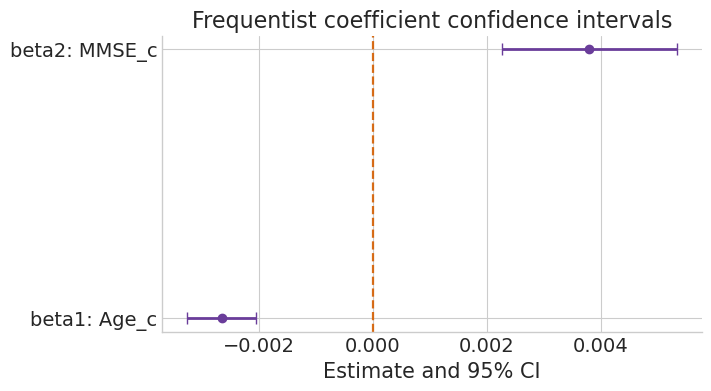

In [255]:
plot_terms = freq_coef_table.iloc[1:].copy()

fig, ax = plt.subplots(figsize=(7, 3.8))
ypos = np.arange(len(plot_terms))
ax.errorbar(
    plot_terms["estimate"],
    ypos,
    xerr=[
        plot_terms["estimate"] - plot_terms["95% CI lower"],
        plot_terms["95% CI upper"] - plot_terms["estimate"],
    ],
    fmt="o",
    color=COLORS["frequentist"],
    lw=2,
    capsize=4,
)
ax.set_yticks(ypos, plot_terms["term"])
add_zero_line(ax)
style_axis(ax, "Frequentist coefficient confidence intervals", "Estimate and 95% CI", "")
plt.show()


### 8.7.61 Variance explained over total variance


In [257]:
ols_nwbv_age = smf.ols("nWBV ~ Age_c", data=simple_df).fit()
ols_nwbv_mmse = smf.ols("nWBV ~ MMSE_c", data=mmse_simple_df).fit()

r2_table = pd.DataFrame(
    [
        {"Model": "nWBV ~ Age", "R^2": ols_nwbv_age.rsquared, "adjusted R^2": ols_nwbv_age.rsquared_adj, "residual standard error": np.sqrt(ols_nwbv_age.mse_resid)},
        {"Model": "nWBV ~ MMSE", "R^2": ols_nwbv_mmse.rsquared, "adjusted R^2": ols_nwbv_mmse.rsquared_adj, "residual standard error": np.sqrt(ols_nwbv_mmse.mse_resid)},
        {"Model": "nWBV ~ Age + MMSE", "R^2": ols_multiple.rsquared, "adjusted R^2": ols_multiple.rsquared_adj, "residual standard error": np.sqrt(ols_multiple.mse_resid)},
    ]
)
display(
    pretty_table(
        r2_table,
        "Table 8.8C: Frequentist R^2 and adjusted R^2",
        formats={
            "R^2": fixed_decimals(3),
            "adjusted R^2": fixed_decimals(3),
            "residual standard error": fixed_decimals(3),
        },
    )
)


Model,R^2,adjusted R^2,residual standard error
nWBV ~ Age,0.311,0.307,0.030
nWBV ~ MMSE,0.104,0.098,0.035
nWBV ~ Age + MMSE,0.407,0.399,0.028


### 8.7.62 Define some useful statistics


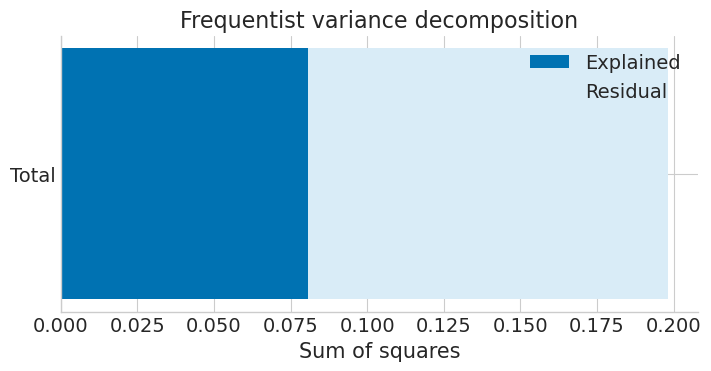

Model-level null,F statistic,p-value
H0: beta1 = beta2 = 0,50.482,<0.0001


In [263]:
fitted_multiple = ols_multiple.fittedvalues.to_numpy()
nwbv_y = multiple_df["nWBV"].to_numpy()
explained_var = np.sum((fitted_multiple - nwbv_y.mean()) ** 2)
residual_var = np.sum((nwbv_y - fitted_multiple) ** 2)

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(["Total"], [explained_var], color=COLORS["mean"], label="Explained")
ax.barh(["Total"], [residual_var], left=[explained_var], color=COLORS["light"], label="Residual")
style_axis(ax, "Frequentist variance decomposition", "Sum of squares", "")
ax.legend()
plt.show()

model_f_table = pd.DataFrame(
    [{"Model-level null": "H0: beta1 = beta2 = 0", "F statistic": ols_multiple.fvalue, "p-value": ols_multiple.f_pvalue}]
)
display(
    pretty_table(
        model_f_table,
        "Table 8.8D: Global F test",
        formats={"F statistic": fixed_decimals(3), "p-value": format_p_value},
    )
)


### 8.7.63 Count the degrees of freedom


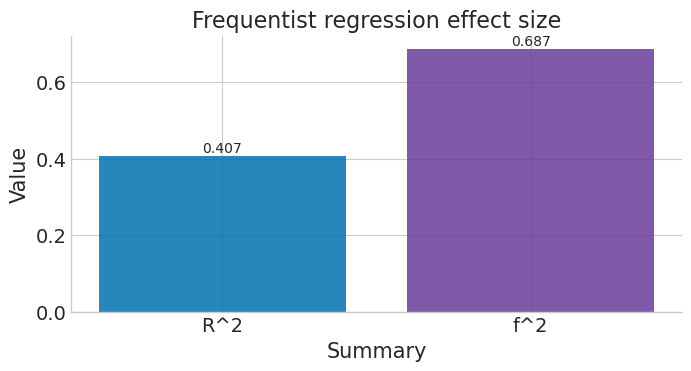

In [264]:
r2_ols_multiple = ols_multiple.rsquared
f2_multiple = r2_ols_multiple / (1 - r2_ols_multiple)

fig, ax = plt.subplots(figsize=(6.8, 3.6))
ax.bar(["R^2", "f^2"], [r2_ols_multiple, f2_multiple], color=[COLORS["mean"], COLORS["frequentist"]], alpha=0.85)
style_axis(ax, "Frequentist regression effect size", "Summary", "Value")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")
plt.show()


<a id="section-88"></a>
## 8.8 Next time
Combining regression with categorical variables.


### 8.8.65 Next time

The linear-model motif continues with categorical predictors, ANOVA-style designs, and interactions.
